# Circuit Analysis with Python
Last update: 26 Aug 2026

<!--
-->

- rewrite to make the focus about Python, JupyterLab and not so much on the circuits themselves, describe how Python is used to analyize the circuits, both numerically and symbollically.
  - what is the value of symbolic solutions?
- ~need to consolidate all the LTSpice schematics in one directory, see `/home/jeff32/Documents/Solving Electrical Engineering Problems with Python Blog/python circuits/Circuit_analysis_with_python_paper/`~
  - rename files
- clean up and finish examples
  - ~remove bridge t-circuit example.~
  - ~finish initial conditions~
  - spell and grammar check
- post to GitHub and link to in paper.
  - ~make some place holders, `Circuit_Analysis_with_Python`, sub folders for LTSpice files, plots, Typst source files, ...~  
- add save command to plots.
- copy text plots and figures to typst
- publish to [About TechRxiv](https://www.ieee.org/publications/techrxiv), [TechRxiv-papers](https://www.techrxiv.org/), https://arxiv.org/, 
  - use pseudonym

---
Note: The purpose of this JypyterLab notebook is to draft a technical paper about circuit analysis with python. Once the contents have been completed, much of the dialog and results will be copied to [Typst](https://typst.app/) for conversion to a PDF. One column per page seems to work best for code figures and equations.

---

**_Abstract_**  
This paper presents a procedure to analyze electric circuits which may contain resistors, capacitors, inductors, Op Amps, dependent and independent sources using the Python programming language. The procedure presented in this paper will use Modified Nodal Analysis to generate the network equations. It is shown that the SymPy and NumPy libraries can be used to generate symbolic network equations from a circuit's netlist and solve those equations with almost no effort. The procedure is efficient and less error prone compared to manual calculations.  

_Keywords:_ Linear Circuit Analysis, Modified Nodal Analysis, Symbolic Analysis, Controlled Sources, Element Stamps, Python, SymPy, NumPy

## Introduction
The purpose of this paper is to describe a procedure implemented in the Python programming language that will automatically generate symbolic network equations from a circuit's netlist. The Python programming language and the associated libraries such as SymPy and NumPy make analyzing electric circuits almost effortless and the JupyterLab Notebooks described in this paper can be used as template for analyzing almost any linear electric circuit.

Circuit analysis is a foundational skill necessary for a broad range of professionals whose work involves the design and development of electronic systems. Electrical Engineers and Circuit Designers are the core audience, as they rely on techniques like Kirchhoff's Laws to create efficient circuits, calculate voltage drops and current flows, and simulate how an electric  circuit will behave before it's ever built. Fields like Power Systems Engineering, Control Systems Engineering and even Physics require this knowledge to understand energy distribution, optimize system performance and analyze complex physical models where circuits are used as analogues. 

The Modified Nodal Analysis (MNA) is an essential extension of standard Nodal Analysis, and its primary benefits revolve around its systematic and comprehensive nature, particularly for computer-aided analysis. The key advantage of MNA is its ability to accommodate many types of circuit elements in a single, unified matrix formulation. Unlike traditional Nodal Analysis, which struggles to directly model voltage sources and components whose current is not easily defined by node voltages (such as dependent voltage sources and inductors), MNA introduces the currents through these elements as additional unknown variables. This standardization makes the process of formulating the circuit equations highly algorithmic and straightforward to automate, forming the backbone of professional circuit simulators like SPICE. Consequently, MNA eliminates the need for manual, ad-hoc techniques like supernodes or source transformations, allowing for the rapid and reliable analysis of large, complex, and linear circuits.

In 1975, a paper titled, _The Modified Nodal Approach to Network Analysis_, was published by @Ho1975. This was the original scholarly paper on the subject. The analysis method they presented allows for the ability to process voltage sources and current-dependent circuit elements in a simple and efficient manner. The paper describes the formulation of the matrices, the use of stamps and a pivot ordering strategy. The authors compare their algorithm to the tableau method, a circuit analysis technique, which was an analysis technique being described in scholarly papers at the time.

The analysis of electric circuits, whether done by hand or with the help of Python and MNA, fundamentally relies on the concept of ideal components. These are theoretical abstractions that possess perfect behavior (e.g., a resistor has only resistance, an inductor has only inductance) and ignore the inevitable imperfections of real-world devices, such as parasitic capacitance, lead resistance, or temperature dependence. 

Furthermore, almost all conventional circuit analysis methods, including Nodal and Mesh analysis, rely on the assumption of a lumped-element model, which assumes the circuit is small enough that electrical effects occur instantaneously throughout the circuit, neglecting the time delay associated with the propagation of electromagnetic fields. This allows us to treat the circuit's current and voltage as functions of time alone, rather than of both position and time (as required for wave propagation or transmission line effects). Finally, the systematic matrix methods discussed (MNA) are designed specifically for linear time-invariant (LTI) circuits, where the relationship between voltage and current is linear (e.g., Ohm's law holds true) and the component values or connections do not change over time.

Symbolic circuit analysis is a formal technique where the behavior or characteristic of a circuit (like voltage gain or impedance) is calculated with the circuit components and frequency (or time) represented by symbols instead of numerical values.

For small circuits, the analytical expression (e.g., a transfer function) explicitly shows how each component affects the circuit's performance metrics (gain, poles, zeros, etc.). This allows a designer to immediately see which elements are dominant and how to modify component values to meet specifications. A symbolic expression remains valid across a range of component values and operating conditions (as long as the underlying model is valid). By using symbolic analysis the network equations in symbolic form can be useful to document a design or to include in a technical paper. 

### Background and Motivation

### Problem Statement

### Proposed Solution

### Paper Organization

## Analysis Method
Modified Nodal Analysis (MNA) was used to obtain the network equations. The MNA procedure provides an algorithmic method for generating a system of independent equations for linear circuit analysis. Once the schematic is drawn and the net list is exported, the network equations and solutions for the node voltages are easily obtained as shown in this paper. A JupyterLab notebook @Tiburonboy2025c was written to perform the analysis and write the content of this paper. The code in the JupyterLab notebook can be used as a template to analyze almost any type of linear circuit.

Laplace transformed circuit elements are a powerful method used in electrical engineering to analyze complex linear circuits, especially those with energy storage elements (inductors and capacitors) and time-varying inputs. This method converts the circuit from the time domain ($t$) into the s-domain (a complex frequency domain) using the Laplace transform. The Laplace transform is a mathematical operation defined by an integral that takes a time-domain function $f(t)$ to an s-domain function $\mathcal{L}\{f(t)\} = F(s)$. In the time domain, circuits with L's and C's are described by differential equations. For instance, the voltage across an inductor is $v_L(t) = L \frac{di_L(t)}{dt}$. When transformed to the s-domain, differentiation becomes simple multiplication by $s$, and integration becomes division by $s$. This makes standard circuit analysis techniques (like nodal or mesh analysis) applicable using only algebra.

The schematics for the example circuits below were drawn using LTSpice and the netlist was exported for the analysis. Drawing a circuit with a schematic capture program and exporting the netlist reduced the possibilities for errors as the analysis proceeds. The analysis begins with generating the network equations from the circuit's netlist by calling:

```Python
report, network_df, df2, A, X, Z = SymMNA.smna(filter_net_list)
```
The function `SymMNA.smna()` is described in @Tiburonboy2024. The SymPy `solve` is capable of working through the algebra to solve the system of equations and can even find the roots of the numerator and denominator polynomials in some cases. Analytic expressions are easily generated for the circuit's node voltages.

Numercial values can be substituded for the component values and NumPy can be used to find numerical solutions for the network equations. 

## Analysis Results
Symbolic analysis presented in this paper employs the MNA technique to generate network equations from the circuit's netlist where the element values are represented by symbols. SymPy is used to solve the system of equations in symbolic form to obtain analytic expressions for the circuit's node voltages. The symbolic expressions can in some cases provide a deeper understanding of how each component contributes to the circuit's operation that can complement numerical simulations.

The following Python modules are used in the prodecure.

In [1]:
from sympy import *
import numpy as np
from tabulate import tabulate
from scipy import signal
import matplotlib.pyplot as plt
import pandas as pd
import SymMNA
from IPython.display import display, Markdown, Math, Latex
init_printing()

In [2]:
import re

The netlists for the example circuits are generated by LTSpice from the schematic. The nodes in the circuits were labeled in the schematic, otherwise LTSpice will use default labels such as N001, N002 etc. and the `SymMNA.smna` function requires integer values for the node numbers and these need to be consecutively ordered with no gaps in the numbering.

Generation of the netlist from a schematic capture program is convenient and less error prone than generating the netlist by hand. A visual inspection of the schematic ensures that the circuit to be analyzed is correct and it follows that the netlist is also correct. This is especially true for larger, more complicated schematics. The procedure for analyzing electrical circuits with Python is best explained by considereing the example circuits described below.

### Example 1 - RLC Network
The circuit shown in the schematic below contains three resistors, one capacitor, one inductor and one independent voltage source. The nodes have been numbered and the reference node is indicated by the ground symbol.  The schematic was drawn using LTSpice and the netlist was expored and copied into the code cell below. 

The circuit is a typical of circuits found in circuit analysis text books. The independed voltage source spans nodes 1 and 2. Typically, these nodes would be considred a super-node when applying KCL to obtain a set of network equations. When using the MNA procedure, extra equations are generated to deal with voltage sourses that span circuit nodes.    

![RLC circuit 1](RLC_network_1.png){#fig-rlc_network_1}

The code in the cell below formulates the network equations from the circuit's netlist using MNA.  

In [3]:
net_list = '''
R1 1 0 3
R2 3 2 7
R3 3 0 11
C 3 1 0.5
L 2 0 1
I1 1 2 2
'''

# generate the MNA matrices. 
report, network_df, i_unk_df, A, X, Z = SymMNA.smna(net_list)

# Put matrices into SymPy 
X = Matrix(X)
Z = Matrix(Z)

# assemble the system of equations
NE_sym = Eq(A*X,Z)

# turn the free symbols into SymPy variables.
var(str(NE_sym.free_symbols).replace('{','').replace('}',''))

# display the network equations
temp = ''
for i in range(len(X)):
    temp += '${:s}$<br>'.format(latex(Eq((A*X)[i:i+1][0],Z[i])))

Markdown(temp)

$- C s v_{3} + v_{1} \left(C s + \frac{1}{R_{1}}\right) = - I_{1}$<br>$I_{L} + \frac{v_{2}}{R_{2}} - \frac{v_{3}}{R_{2}} = I_{1}$<br>$- C s v_{1} + v_{3} \left(C s + \frac{1}{R_{3}} + \frac{1}{R_{2}}\right) - \frac{v_{2}}{R_{2}} = 0$<br>$- I_{L} L s + v_{2} = 0$<br>

The following is some test code for formulating equations for Typst.

In [4]:
temp

'$- C s v_{3} + v_{1} \\left(C s + \\frac{1}{R_{1}}\\right) = - I_{1}$<br>$I_{L} + \\frac{v_{2}}{R_{2}} - \\frac{v_{3}}{R_{2}} = I_{1}$<br>$- C s v_{1} + v_{3} \\left(C s + \\frac{1}{R_{3}} + \\frac{1}{R_{2}}\\right) - \\frac{v_{2}}{R_{2}} = 0$<br>$- I_{L} L s + v_{2} = 0$<br>'

The equations need to look like this for Typst
```
$
  I_1 = v_1/R_5 - v_4/R_5 \
  - I_1 = v_2 (1/R_4 + 1/R_3) - v_3/R_4 \
  0 = - I_"V1" + v_3 (1/R_4 + 1/R_2) - v_2/R_4 \
  0 = I_"V1" + v_4 (1/R_5 + 1/R_1) - v_1/R_5 \
  V_1 = - v_3 + v_4
$
```

In [5]:
# build equations for Typst, need to add subscript numbers '_'
temp = '$'
for i in range(shape(NE_sym.lhs)[0]):
    temp += '{:s} &= {:s} % '.format(str(NE_sym.rhs[i]),str(NE_sym.lhs[i]))
temp += '$'
temp

'$-I1 &= -C*s*v3 + v1*(C*s + 1/R1) % I1 &= I_L + v2/R2 - v3/R2 % 0 &= -C*s*v1 + v3*(C*s + 1/R3 + 1/R2) - v2/R2 % 0 &= -I_L*L*s + v2 % $'

Remove `*`, replace `%` with `\`, subscript most variables.

In [6]:
temp = temp.replace('*','').replace('%','\\n')
temp

'$-I1 &= -Csv3 + v1(Cs + 1/R1) \\n I1 &= I_L + v2/R2 - v3/R2 \\n 0 &= -Csv1 + v3(Cs + 1/R3 + 1/R2) - v2/R2 \\n 0 &= -I_LLs + v2 \\n $'

Apply subscripts to most variables, some manual editing will be required.

In [7]:
pattern = r'([a-zA-Z])(\d)'
replacement = r'\1_\2'
new_string = re.sub(pattern, replacement, temp)
new_string

'$-I_1 &= -Csv_3 + v_1(Cs + 1/R_1) \\n I_1 &= I_L + v_2/R_2 - v_3/R_2 \\n 0 &= -Csv_1 + v_3(Cs + 1/R_3 + 1/R_2) - v_2/R_2 \\n 0 &= -I_LLs + v_2 \\n $'

Manually edit this string to fix any problems and copy paste into Typst.

Use the `solve` function to obtain the expressions for the node voltages and unknown currents. The node voltages in symbolic form are displayed below.

In [8]:
U_sym = solve(NE_sym,X)

temp = ''
for i in U_sym.keys():
    temp += '${:s} = {:s}$<br>'.format(latex(i),latex(U_sym[i]))

Markdown(temp)

$v_{1} = \frac{- C I_{1} R_{1} R_{2} R_{3} s - I_{1} L R_{1} s - I_{1} R_{1} R_{2} - I_{1} R_{1} R_{3}}{C L R_{1} s^{2} + C L R_{3} s^{2} + C R_{1} R_{2} s + C R_{1} R_{3} s + C R_{2} R_{3} s + L s + R_{2} + R_{3}}$<br>$v_{2} = \frac{C I_{1} L R_{1} R_{2} s^{2} + C I_{1} L R_{2} R_{3} s^{2} + I_{1} L R_{2} s + I_{1} L R_{3} s}{C L R_{1} s^{2} + C L R_{3} s^{2} + C R_{1} R_{2} s + C R_{1} R_{3} s + C R_{2} R_{3} s + L s + R_{2} + R_{3}}$<br>$v_{3} = \frac{- C I_{1} R_{1} R_{2} R_{3} s + I_{1} L R_{3} s}{C L R_{1} s^{2} + C L R_{3} s^{2} + C R_{1} R_{2} s + C R_{1} R_{3} s + C R_{2} R_{3} s + L s + R_{2} + R_{3}}$<br>$I_{L} = \frac{C I_{1} R_{1} R_{2} s + C I_{1} R_{2} R_{3} s + I_{1} R_{2} + I_{1} R_{3}}{C L R_{1} s^{2} + C L R_{3} s^{2} + C R_{1} R_{2} s + C R_{1} R_{3} s + C R_{2} R_{3} s + L s + R_{2} + R_{3}}$<br>

The following is some test code for formulating equations for Typst.

In [9]:
temp

'$v_{1} = \\frac{- C I_{1} R_{1} R_{2} R_{3} s - I_{1} L R_{1} s - I_{1} R_{1} R_{2} - I_{1} R_{1} R_{3}}{C L R_{1} s^{2} + C L R_{3} s^{2} + C R_{1} R_{2} s + C R_{1} R_{3} s + C R_{2} R_{3} s + L s + R_{2} + R_{3}}$<br>$v_{2} = \\frac{C I_{1} L R_{1} R_{2} s^{2} + C I_{1} L R_{2} R_{3} s^{2} + I_{1} L R_{2} s + I_{1} L R_{3} s}{C L R_{1} s^{2} + C L R_{3} s^{2} + C R_{1} R_{2} s + C R_{1} R_{3} s + C R_{2} R_{3} s + L s + R_{2} + R_{3}}$<br>$v_{3} = \\frac{- C I_{1} R_{1} R_{2} R_{3} s + I_{1} L R_{3} s}{C L R_{1} s^{2} + C L R_{3} s^{2} + C R_{1} R_{2} s + C R_{1} R_{3} s + C R_{2} R_{3} s + L s + R_{2} + R_{3}}$<br>$I_{L} = \\frac{C I_{1} R_{1} R_{2} s + C I_{1} R_{2} R_{3} s + I_{1} R_{2} + I_{1} R_{3}}{C L R_{1} s^{2} + C L R_{3} s^{2} + C R_{1} R_{2} s + C R_{1} R_{3} s + C R_{2} R_{3} s + L s + R_{2} + R_{3}}$<br>'

In [10]:
# build equations for Typst, need to add subscript numbers '_'
temp = '$'
for i in U_sym.keys():
    temp += '{:s} &= {:s} % '.format(latex(i),latex(U_sym[i]))

temp += '$'
temp

'$v_{1} &= \\frac{- C I_{1} R_{1} R_{2} R_{3} s - I_{1} L R_{1} s - I_{1} R_{1} R_{2} - I_{1} R_{1} R_{3}}{C L R_{1} s^{2} + C L R_{3} s^{2} + C R_{1} R_{2} s + C R_{1} R_{3} s + C R_{2} R_{3} s + L s + R_{2} + R_{3}} % v_{2} &= \\frac{C I_{1} L R_{1} R_{2} s^{2} + C I_{1} L R_{2} R_{3} s^{2} + I_{1} L R_{2} s + I_{1} L R_{3} s}{C L R_{1} s^{2} + C L R_{3} s^{2} + C R_{1} R_{2} s + C R_{1} R_{3} s + C R_{2} R_{3} s + L s + R_{2} + R_{3}} % v_{3} &= \\frac{- C I_{1} R_{1} R_{2} R_{3} s + I_{1} L R_{3} s}{C L R_{1} s^{2} + C L R_{3} s^{2} + C R_{1} R_{2} s + C R_{1} R_{3} s + C R_{2} R_{3} s + L s + R_{2} + R_{3}} % I_{L} &= \\frac{C I_{1} R_{1} R_{2} s + C I_{1} R_{2} R_{3} s + I_{1} R_{2} + I_{1} R_{3}}{C L R_{1} s^{2} + C L R_{3} s^{2} + C R_{1} R_{2} s + C R_{1} R_{3} s + C R_{2} R_{3} s + L s + R_{2} + R_{3}} % $'

Remove `*`, replace `%` with `\`, subscript most variables.

In [11]:
temp = temp.replace('*','').replace('%','\\n')
temp

'$v_{1} &= \\frac{- C I_{1} R_{1} R_{2} R_{3} s - I_{1} L R_{1} s - I_{1} R_{1} R_{2} - I_{1} R_{1} R_{3}}{C L R_{1} s^{2} + C L R_{3} s^{2} + C R_{1} R_{2} s + C R_{1} R_{3} s + C R_{2} R_{3} s + L s + R_{2} + R_{3}} \\n v_{2} &= \\frac{C I_{1} L R_{1} R_{2} s^{2} + C I_{1} L R_{2} R_{3} s^{2} + I_{1} L R_{2} s + I_{1} L R_{3} s}{C L R_{1} s^{2} + C L R_{3} s^{2} + C R_{1} R_{2} s + C R_{1} R_{3} s + C R_{2} R_{3} s + L s + R_{2} + R_{3}} \\n v_{3} &= \\frac{- C I_{1} R_{1} R_{2} R_{3} s + I_{1} L R_{3} s}{C L R_{1} s^{2} + C L R_{3} s^{2} + C R_{1} R_{2} s + C R_{1} R_{3} s + C R_{2} R_{3} s + L s + R_{2} + R_{3}} \\n I_{L} &= \\frac{C I_{1} R_{1} R_{2} s + C I_{1} R_{2} R_{3} s + I_{1} R_{2} + I_{1} R_{3}}{C L R_{1} s^{2} + C L R_{3} s^{2} + C R_{1} R_{2} s + C R_{1} R_{3} s + C R_{2} R_{3} s + L s + R_{2} + R_{3}} \\n $'

Apply subscripts to most variables, some manual editing will be required.

In [12]:
pattern = r'([a-zA-Z])(\d)'
replacement = r'\1_\2'
new_string = re.sub(pattern, replacement, temp)
new_string

'$v_{1} &= \\frac{- C I_{1} R_{1} R_{2} R_{3} s - I_{1} L R_{1} s - I_{1} R_{1} R_{2} - I_{1} R_{1} R_{3}}{C L R_{1} s^{2} + C L R_{3} s^{2} + C R_{1} R_{2} s + C R_{1} R_{3} s + C R_{2} R_{3} s + L s + R_{2} + R_{3}} \\n v_{2} &= \\frac{C I_{1} L R_{1} R_{2} s^{2} + C I_{1} L R_{2} R_{3} s^{2} + I_{1} L R_{2} s + I_{1} L R_{3} s}{C L R_{1} s^{2} + C L R_{3} s^{2} + C R_{1} R_{2} s + C R_{1} R_{3} s + C R_{2} R_{3} s + L s + R_{2} + R_{3}} \\n v_{3} &= \\frac{- C I_{1} R_{1} R_{2} R_{3} s + I_{1} L R_{3} s}{C L R_{1} s^{2} + C L R_{3} s^{2} + C R_{1} R_{2} s + C R_{1} R_{3} s + C R_{2} R_{3} s + L s + R_{2} + R_{3}} \\n I_{L} &= \\frac{C I_{1} R_{1} R_{2} s + C I_{1} R_{2} R_{3} s + I_{1} R_{2} + I_{1} R_{3}}{C L R_{1} s^{2} + C L R_{3} s^{2} + C R_{1} R_{2} s + C R_{1} R_{3} s + C R_{2} R_{3} s + L s + R_{2} + R_{3}} \\n $'

Manually edit this string to fix any problems and copy paste into Typst.

Numerical values can be substituted into the equations.

In [13]:
element_values = SymMNA.get_part_values(network_df)

# substitute numerical values
NE = NE_sym.subs(element_values)

# solve and display
U = solve(NE,X)

temp = ''
for i in U.keys():
    temp += '${:s} = {:s}$<br>'.format(latex(i),latex(U[i]))

Markdown(temp)

$v_{1} = \frac{- 474.0 s - 216.0}{14.0 s^{2} + 133.0 s + 36.0}$<br>$v_{2} = \frac{196.0 s^{2} + 72.0 s}{14.0 s^{2} + 133.0 s + 36.0}$<br>$v_{3} = - \frac{418.0 s}{14.0 s^{2} + 133.0 s + 36.0}$<br>$I_{L} = \frac{196.0 s + 72.0}{14.0 s^{2} + 133.0 s + 36.0}$<br>

The following is some test code for formulating equations for Typst.

In [14]:
temp

'$v_{1} = \\frac{- 474.0 s - 216.0}{14.0 s^{2} + 133.0 s + 36.0}$<br>$v_{2} = \\frac{196.0 s^{2} + 72.0 s}{14.0 s^{2} + 133.0 s + 36.0}$<br>$v_{3} = - \\frac{418.0 s}{14.0 s^{2} + 133.0 s + 36.0}$<br>$I_{L} = \\frac{196.0 s + 72.0}{14.0 s^{2} + 133.0 s + 36.0}$<br>'

In [15]:
# build equations for Typst, need to add subscript numbers '_'
temp = '$'
for i in U.keys():
    temp += '{:s} &= {:s} % '.format(latex(i),latex(U[i]))

temp += '$'
temp

'$v_{1} &= \\frac{- 474.0 s - 216.0}{14.0 s^{2} + 133.0 s + 36.0} % v_{2} &= \\frac{196.0 s^{2} + 72.0 s}{14.0 s^{2} + 133.0 s + 36.0} % v_{3} &= - \\frac{418.0 s}{14.0 s^{2} + 133.0 s + 36.0} % I_{L} &= \\frac{196.0 s + 72.0}{14.0 s^{2} + 133.0 s + 36.0} % $'

Remove `*`, replace `%` with `\`, subscript most variables.

In [16]:
temp = temp.replace('*','').replace('%','\\n')
temp

'$v_{1} &= \\frac{- 474.0 s - 216.0}{14.0 s^{2} + 133.0 s + 36.0} \\n v_{2} &= \\frac{196.0 s^{2} + 72.0 s}{14.0 s^{2} + 133.0 s + 36.0} \\n v_{3} &= - \\frac{418.0 s}{14.0 s^{2} + 133.0 s + 36.0} \\n I_{L} &= \\frac{196.0 s + 72.0}{14.0 s^{2} + 133.0 s + 36.0} \\n $'

Apply subscripts to most variables, some manual editing will be required.

In [17]:
pattern = r'([a-zA-Z])(\d)'
replacement = r'\1_\2'
new_string = re.sub(pattern, replacement, temp)
new_string

'$v_{1} &= \\frac{- 474.0 s - 216.0}{14.0 s^{2} + 133.0 s + 36.0} \\n v_{2} &= \\frac{196.0 s^{2} + 72.0 s}{14.0 s^{2} + 133.0 s + 36.0} \\n v_{3} &= - \\frac{418.0 s}{14.0 s^{2} + 133.0 s + 36.0} \\n I_{L} &= \\frac{196.0 s + 72.0}{14.0 s^{2} + 133.0 s + 36.0} \\n $'

Manually edit this string to fix any problems and copy paste into Typst.

The circuit's node voltages and unknown currents can be solved for at individual frequencies. In the code cell below, a frequency of 1 Hz is used to evaluate the equations at a particular frequency.

In [18]:
freq = 1 # Hz
omega = 2*np.pi*freq

NE = NE_sym.subs(element_values)
NE_w1 = NE.subs({s:1j*omega})

U_w1 = solve(NE_w1,X)

table_header = ['unknown', 'mag','phase, deg']
table_row = []

for name, value in U_w1.items():
    table_row.append([str(name),float(abs(value)),float(arg(value)*180/np.pi)])

print(tabulate(table_row, headers=table_header,colalign = ('left','decimal','decimal'),tablefmt="simple",floatfmt=('5s','.6f','.6f')))

unknown         mag    phase, deg
---------  --------  ------------
v1         3.039233    144.122962
v2         7.889024     54.925157
v3         2.673146    148.271150
I_L        1.255577    -35.074843


Code to generate formatted text for Typst for a table 

Typst table format

```
#show table.cell.where(y: 0): set text(weight: "bold")

#figure(
  table(
    columns: 4,
    stroke: none,

    table.header[Test Item][Specification][Test Result][Compliance],
    [Voltage], [220V ± 5%], [218V], [Pass],
    [Current], [5A ± 0.5A], [4.2A], [Fail],
  ),
  caption: [Probe results for design A],
) <probe-a>
```

In [19]:
typst_table_string = 'table.header[unknown][mag][phase, deg],\n'

for name, value in U_w1.items():
    if str(name)[0] == 'I':
        unit = 'device current'
    else:
        unit = 'voltage'
    typst_table_string += f'[${name}$],[{float(abs(value)):,.6f}],[{float(arg(value)*180/np.pi):,.6f}],\n'

print(typst_table_string)

table.header[unknown][mag][phase, deg],
[$v1$],[3.039233],[144.122962],
[$v2$],[7.889024],[54.925157],
[$v3$],[2.673146],[148.271150],
[$I_L$],[1.255577],[-35.074843],



In [20]:
typst_table_string

'table.header[unknown][mag][phase, deg],\n[$v1$],[3.039233],[144.122962],\n[$v2$],[7.889024],[54.925157],\n[$v3$],[2.673146],[148.271150],\n[$I_L$],[1.255577],[-35.074843],\n'

The results obtained above agree with the solution generated by LTSpice. 

### Example 2 - Transfer Function
A transfer function is a fundamental mathematical representation used in circuit design to characterize the relationship between a circuit's output signal and its input signal. Specifically, it is defined as the ratio of the Laplace transform of the output (response) to the Laplace transform of the input (excitation), assuming all initial conditions are zero.  This function, typically denoted as $H(s)$ where $s$ is the complex frequency variable $(j\omega)$, allows engineers to analyze and predict the circuit's behavior across different frequencies. By examining the poles (roots of the denominator) and zeros (roots of the numerator) of the transfer function, one can determine crucial circuit properties such as gain, stability, frequency response (e.g., whether it acts as a low-pass or high-pass filter), and transient behavior, making it an indispensable tool for designing and optimizing filters, amplifiers, and control systems.

This example walks through the Python code used to find the transfer function of the circuit shown in @fig-unity_gain_2P_LPF_sch.  

![Schematic of a unity gain two pole low pass filter.](Unity_gain_2P_LPF.png){#fig-unity_gain_2P_LPF_sch}

The circuit above is a 2nd order low pass filter from @Stout1976. The schematic of the circuit is shown with each node annotated. The filter shown is being used to illustrate the application of Python to obtain the transfer function, $\frac {V_2} {V_1}$.

This circuit has two complex poles and by proper choice of $R_1$, $R_2$, $C_1$ and $C_2$ the complex poles can be positioned to realize Bessel, Butterworth or Chebyshev filter characteristics. The component values shown in the schematic produce a low pass filter with a cut off frequency of 1000 Hz and a 3 dB Chebyshev response.

The Python MNA code supports the Op Amp component type designated with the letter 'O' and is shown on the send line of the netlist.

In [21]:
net_list = '''
R1 3 1 49.4e3
O1 2 4 2
V1 1 0 1
R2 4 3 49.4e3
C2 4 0 1470e-12
C1 2 3 0.01e-6
'''

# call the symbolic modified nodal analysis function to generate the MNA matrices.
report, network_df, i_unk_df, A, X, Z = SymMNA.smna(net_list)

# assemble and build the network equations.
# Put matrices into SymPy 
X = Matrix(X)
Z = Matrix(Z)

NE_sym = Eq(A*X,Z)

# turn the free symbols into SymPy variables.
var(str(NE_sym.free_symbols).replace('{','').replace('}',''))

# construct a dictionary of element values.
element_values = SymMNA.get_part_values(network_df)

# display the equations
temp = ''
for i in range(shape(NE_sym.lhs)[0]):
    temp += '${:s} = {:s}$<br>'.format(latex(NE_sym.rhs[i]),latex(NE_sym.lhs[i]))
Markdown(temp)

$0 = I_{V1} + \frac{v_{1}}{R_{1}} - \frac{v_{3}}{R_{1}}$<br>$0 = C_{1} s v_{2} - C_{1} s v_{3} + I_{O1}$<br>$0 = - C_{1} s v_{2} + v_{3} \left(C_{1} s + \frac{1}{R_{2}} + \frac{1}{R_{1}}\right) - \frac{v_{4}}{R_{2}} - \frac{v_{1}}{R_{1}}$<br>$0 = v_{4} \left(C_{2} s + \frac{1}{R_{2}}\right) - \frac{v_{3}}{R_{2}}$<br>$V_{1} = v_{1}$<br>$0 = v_{2} - v_{4}$<br>

The following is some test code for formulating equations for Typst.

In [22]:
temp

'$0 = I_{V1} + \\frac{v_{1}}{R_{1}} - \\frac{v_{3}}{R_{1}}$<br>$0 = C_{1} s v_{2} - C_{1} s v_{3} + I_{O1}$<br>$0 = - C_{1} s v_{2} + v_{3} \\left(C_{1} s + \\frac{1}{R_{2}} + \\frac{1}{R_{1}}\\right) - \\frac{v_{4}}{R_{2}} - \\frac{v_{1}}{R_{1}}$<br>$0 = v_{4} \\left(C_{2} s + \\frac{1}{R_{2}}\\right) - \\frac{v_{3}}{R_{2}}$<br>$V_{1} = v_{1}$<br>$0 = v_{2} - v_{4}$<br>'

In [23]:
# build equations for Typst, need to add subscript numbers '_'
temp = '$'
for i in range(shape(NE_sym.lhs)[0]):
    temp += '{:s} &= {:s} % '.format(str(NE_sym.rhs[i]),str(NE_sym.lhs[i]))
temp += '$'
temp

'$0 &= I_V1 + v1/R1 - v3/R1 % 0 &= C1*s*v2 - C1*s*v3 + I_O1 % 0 &= -C1*s*v2 + v3*(C1*s + 1/R2 + 1/R1) - v4/R2 - v1/R1 % 0 &= v4*(C2*s + 1/R2) - v3/R2 % V1 &= v1 % 0 &= v2 - v4 % $'

Remove `*`, replace `%` with `\`, subscript most variables.

In [24]:
temp = temp.replace('*','').replace('%','\\n')
temp

'$0 &= I_V1 + v1/R1 - v3/R1 \\n 0 &= C1sv2 - C1sv3 + I_O1 \\n 0 &= -C1sv2 + v3(C1s + 1/R2 + 1/R1) - v4/R2 - v1/R1 \\n 0 &= v4(C2s + 1/R2) - v3/R2 \\n V1 &= v1 \\n 0 &= v2 - v4 \\n $'

Apply subscripts to most variables, some manual editing will be required.

In [25]:
pattern = r'([a-zA-Z])(\d)'
replacement = r'\1_\2'
new_string = re.sub(pattern, replacement, temp)
new_string

'$0 &= I_V_1 + v_1/R_1 - v_3/R_1 \\n 0 &= C_1sv_2 - C_1sv_3 + I_O_1 \\n 0 &= -C_1sv_2 + v_3(C_1s + 1/R_2 + 1/R_1) - v_4/R_2 - v_1/R_1 \\n 0 &= v_4(C_2s + 1/R_2) - v_3/R_2 \\n V_1 &= v_1 \\n 0 &= v_2 - v_4 \\n $'

Manually edit this string to fix any problems and copy paste into Typst.

Use the SymPy function `solve` to deterermine the unknown node voltages and device currents.

In [26]:
U_sym = solve(NE_sym,X)

temp = ''
for i in U_sym.keys():
    temp += '${:s} = {:s}$<br>'.format(latex(i),latex(U_sym[i]))

Markdown(temp)

$v_{1} = V_{1}$<br>$v_{2} = \frac{V_{1}}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1}$<br>$v_{3} = \frac{C_{2} R_{2} V_{1} s + V_{1}}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1}$<br>$v_{4} = \frac{V_{1}}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1}$<br>$I_{V1} = \frac{- C_{1} C_{2} R_{2} V_{1} s^{2} - C_{2} V_{1} s}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1}$<br>$I_{O1} = \frac{C_{1} C_{2} R_{2} V_{1} s^{2}}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1}$<br>

The following is some test code for formulating equations for Typst.

In [27]:
temp

'$v_{1} = V_{1}$<br>$v_{2} = \\frac{V_{1}}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1}$<br>$v_{3} = \\frac{C_{2} R_{2} V_{1} s + V_{1}}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1}$<br>$v_{4} = \\frac{V_{1}}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1}$<br>$I_{V1} = \\frac{- C_{1} C_{2} R_{2} V_{1} s^{2} - C_{2} V_{1} s}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1}$<br>$I_{O1} = \\frac{C_{1} C_{2} R_{2} V_{1} s^{2}}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1}$<br>'

In [28]:
# build equations for Typst, need to add subscript numbers '_'
temp = '$'
for i in U_sym.keys():
    temp += '{:s} &= {:s} % '.format(latex(i),latex(U_sym[i]))

temp += '$'
temp

'$v_{1} &= V_{1} % v_{2} &= \\frac{V_{1}}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1} % v_{3} &= \\frac{C_{2} R_{2} V_{1} s + V_{1}}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1} % v_{4} &= \\frac{V_{1}}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1} % I_{V1} &= \\frac{- C_{1} C_{2} R_{2} V_{1} s^{2} - C_{2} V_{1} s}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1} % I_{O1} &= \\frac{C_{1} C_{2} R_{2} V_{1} s^{2}}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1} % $'

Remove `*`, replace `%` with `\`, subscript most variables.

In [29]:
temp = temp.replace('*','').replace('%','\\n')
temp

'$v_{1} &= V_{1} \\n v_{2} &= \\frac{V_{1}}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1} \\n v_{3} &= \\frac{C_{2} R_{2} V_{1} s + V_{1}}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1} \\n v_{4} &= \\frac{V_{1}}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1} \\n I_{V1} &= \\frac{- C_{1} C_{2} R_{2} V_{1} s^{2} - C_{2} V_{1} s}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1} \\n I_{O1} &= \\frac{C_{1} C_{2} R_{2} V_{1} s^{2}}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1} \\n $'

Apply subscripts to most variables, some manual editing will be required.

In [30]:
pattern = r'([a-zA-Z])(\d)'
replacement = r'\1_\2'
new_string = re.sub(pattern, replacement, temp)
new_string

'$v_{1} &= V_{1} \\n v_{2} &= \\frac{V_{1}}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1} \\n v_{3} &= \\frac{C_{2} R_{2} V_{1} s + V_{1}}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1} \\n v_{4} &= \\frac{V_{1}}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1} \\n I_{V_1} &= \\frac{- C_{1} C_{2} R_{2} V_{1} s^{2} - C_{2} V_{1} s}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1} \\n I_{O_1} &= \\frac{C_{1} C_{2} R_{2} V_{1} s^{2}}{C_{1} C_{2} R_{1} R_{2} s^{2} + C_{2} R_{1} s + C_{2} R_{2} s + 1} \\n $'

Manually edit this string to fix any problems and copy paste into Typst.

The symbolic transfer function, $H_{sym}=\frac {v_2}{v_1}$ is the ratio of $v_2$ to $v_1$.

In [31]:
H_sym = (U_sym[v2]/U_sym[v1]).simplify().collect(s)
Markdown('$H(s) = {:s}$'.format(latex(H_sym)))

$H(s) = \frac{1}{C_{1} C_{2} R_{1} R_{2} s^{2} + s \left(C_{2} R_{1} + C_{2} R_{2}\right) + 1}$

In [32]:
str('$H(s) = {:s}$'.format(latex(H_sym)))

'$H(s) = \\frac{1}{C_{1} C_{2} R_{1} R_{2} s^{2} + s \\left(C_{2} R_{1} + C_{2} R_{2}\\right) + 1}$'

As shown above the denominator of $H(s)$ is a 2nd order polynominal in $s$. When using the standardized notation for damping ratio and natural frequency, the coefficients of the denominator polynominal can be equated to these quantities and expressed in terms of the circuit's component values. The standard notation is: $s^2 + 2\zeta\omega_n s + \omega_n^2$, where $\zeta$ is the damping ratio and $\omega_n$ is the natural frequency. The Quality Factor ($Q$) is a dimensionless quantity representing energy loss per cycle relative to the stored energy.

Getting the numerator and demoninator of $H(s)$ by using the `fraction` function, which returns a pair with the expression’s numerator and denominator.

In [33]:
H_sym_num, H_sym_denom = fraction(H_sym)

The denominator polynomial is:

In [34]:
Markdown('$D(s)={:s}$'.format(latex(H_sym_denom.collect(s))))

$D(s)=C_{1} C_{2} R_{1} R_{2} s^{2} + s \left(C_{2} R_{1} + C_{2} R_{2}\right) + 1$

In [35]:
str('$D(s)={:s}$'.format(latex(H_sym_denom.collect(s))))

'$D(s)=C_{1} C_{2} R_{1} R_{2} s^{2} + s \\left(C_{2} R_{1} + C_{2} R_{2}\\right) + 1$'

The coefficients of each Laplace term can be equated to the variables $b_2$, $b_1$ and $b_0$ in the expression: 

$b_2s^2+b_1s+b_0$

where $b_2$, $b_1$ and $b_0$ are:

In [36]:
b2 = H_sym_denom.coeff(s**2)
b1 = H_sym_denom.coeff(s**1)
b0 = (H_sym_denom - b1*s*1 - b2*s**2).expand()
Markdown('<p>$b_2={:s}$</p><p>$b_1={:s}$</p><p>$b_0={:s}$</p>'.format(latex(b2),latex(b1),latex(b0)))

<p>$b_2=C_{1} C_{2} R_{1} R_{2}$</p><p>$b_1=C_{2} R_{1} + C_{2} R_{2}$</p><p>$b_0=1$</p>

In [37]:
temp = str('<p>$b_2={:s}$</p><p>$b_1={:s}$</p><p>$b_0={:s}$</p>'.format(latex(b2),latex(b1),latex(b0)))

The following is some test code for formulating equations for Typst.

Remove `*`, replace `%` with `\`, subscript most variables.

In [38]:
temp = temp.replace('*','').replace('%','\\n')
temp

'<p>$b_2=C_{1} C_{2} R_{1} R_{2}$</p><p>$b_1=C_{2} R_{1} + C_{2} R_{2}$</p><p>$b_0=1$</p>'

Apply subscripts to most variables, some manual editing will be required.

In [39]:
pattern = r'([a-zA-Z])(\d)'
replacement = r'\1_\2'
new_string = re.sub(pattern, replacement, temp)
new_string

'<p>$b_2=C_{1} C_{2} R_{1} R_{2}$</p><p>$b_1=C_{2} R_{1} + C_{2} R_{2}$</p><p>$b_0=1$</p>'

Manually edit this string to fix any problems and copy paste into Typst.

Equating the coefficients, $\omega_n^2=\frac{b_0}{b_2}$, and rearranging the terms, $\omega_n=\sqrt {\frac{b_0}{b_2}}$, we can obtain the expression for the natural frequency in terms of the component values.

In [40]:
omega_n = sqrt(b0/b2).simplify()
Markdown('The natural frequency, $\omega_n={:s}$'.format(latex(omega_n)))

The natural frequency, $\omega_n=\sqrt{\frac{1}{C_{1} C_{2} R_{1} R_{2}}}$

The coefficient of the $s$ term is:

$\frac {\omega_n}{Q}=\frac {b_1}{b_2}$

and rearranging the terms, we get the quality factor:

$Q=\frac {b_2 \omega_n}{b_1}$

In [41]:
quality_factor = (b2*omega_n/b1).simplify()
Markdown('The quality factor, $Q={:s}$'.format(latex(quality_factor)))

The quality factor, $Q=\frac{C_{1} R_{1} R_{2} \sqrt{\frac{1}{C_{1} C_{2} R_{1} R_{2}}}}{R_{1} + R_{2}}$

In [42]:
zeta = (1/(2*quality_factor)).simplify()
Markdown('The damping ratio, $\zeta={:s}$'.format(latex(zeta)))

The damping ratio, $\zeta=\frac{R_{1} + R_{2}}{2 C_{1} R_{1} R_{2} \sqrt{\frac{1}{C_{1} C_{2} R_{1} R_{2}}}}$

Put the component values into the equations and display the network equations with numerical component values.

In [43]:
NE = NE_sym.subs(element_values)

temp = ''
for i in range(shape(NE.lhs)[0]):
    temp += '${:s} = {:s}$<br>'.format(latex(NE.rhs[i]),latex(NE.lhs[i]))

Markdown(temp)

$0 = I_{V1} + 2.02429149797571 \cdot 10^{-5} v_{1} - 2.02429149797571 \cdot 10^{-5} v_{3}$<br>$0 = I_{O1} + 1.0 \cdot 10^{-8} s v_{2} - 1.0 \cdot 10^{-8} s v_{3}$<br>$0 = - 1.0 \cdot 10^{-8} s v_{2} - 2.02429149797571 \cdot 10^{-5} v_{1} + v_{3} \cdot \left(1.0 \cdot 10^{-8} s + 4.04858299595142 \cdot 10^{-5}\right) - 2.02429149797571 \cdot 10^{-5} v_{4}$<br>$0 = - 2.02429149797571 \cdot 10^{-5} v_{3} + v_{4} \cdot \left(1.47 \cdot 10^{-9} s + 2.02429149797571 \cdot 10^{-5}\right)$<br>$1.0 = v_{1}$<br>$0 = v_{2} - v_{4}$<br>

Solve for voltages and currents and display the results.

In [44]:
U = solve(NE,X)

temp = ''
for i in U.keys():
    temp += '${:s} = {:s}$<br>'.format(latex(i),latex(U[i]))

Markdown(temp)

$v_{1} = 1.0$<br>$v_{2} = \frac{1.36591868959225 \cdot 10^{28}}{4.9 \cdot 10^{20} s^{2} + 1.9838056680162 \cdot 10^{24} s + 1.36591868959225 \cdot 10^{28}}$<br>$v_{3} = \frac{9.91902834008098 \cdot 10^{23} s + 1.36591868959225 \cdot 10^{28}}{4.9 \cdot 10^{20} s^{2} + 1.9838056680162 \cdot 10^{24} s + 1.36591868959225 \cdot 10^{28}}$<br>$v_{4} = \frac{1.36591868959225 \cdot 10^{28}}{4.9 \cdot 10^{20} s^{2} + 1.9838056680162 \cdot 10^{24} s + 1.36591868959225 \cdot 10^{28}}$<br>$I_{V1} = \frac{- 9.91902834008098 \cdot 10^{26} s^{2} - 2.0079004737006 \cdot 10^{30} s}{4.9 \cdot 10^{31} s^{2} + 1.9838056680162 \cdot 10^{35} s + 1.36591868959225 \cdot 10^{39}}$<br>$I_{O1} = \frac{9.91902834008098 \cdot 10^{15} s^{2}}{4.9 \cdot 10^{20} s^{2} + 1.9838056680162 \cdot 10^{24} s + 1.36591868959225 \cdot 10^{28}}$<br>

The following is some test code for formulating equations for Typst.

In [45]:
temp

'$v_{1} = 1.0$<br>$v_{2} = \\frac{1.36591868959225 \\cdot 10^{28}}{4.9 \\cdot 10^{20} s^{2} + 1.9838056680162 \\cdot 10^{24} s + 1.36591868959225 \\cdot 10^{28}}$<br>$v_{3} = \\frac{9.91902834008098 \\cdot 10^{23} s + 1.36591868959225 \\cdot 10^{28}}{4.9 \\cdot 10^{20} s^{2} + 1.9838056680162 \\cdot 10^{24} s + 1.36591868959225 \\cdot 10^{28}}$<br>$v_{4} = \\frac{1.36591868959225 \\cdot 10^{28}}{4.9 \\cdot 10^{20} s^{2} + 1.9838056680162 \\cdot 10^{24} s + 1.36591868959225 \\cdot 10^{28}}$<br>$I_{V1} = \\frac{- 9.91902834008098 \\cdot 10^{26} s^{2} - 2.0079004737006 \\cdot 10^{30} s}{4.9 \\cdot 10^{31} s^{2} + 1.9838056680162 \\cdot 10^{35} s + 1.36591868959225 \\cdot 10^{39}}$<br>$I_{O1} = \\frac{9.91902834008098 \\cdot 10^{15} s^{2}}{4.9 \\cdot 10^{20} s^{2} + 1.9838056680162 \\cdot 10^{24} s + 1.36591868959225 \\cdot 10^{28}}$<br>'

In [46]:
# build equations for Typst, need to add subscript numbers '_'
temp = '$'
for i in U.keys():
    temp += '{:s} &= {:s} % '.format(latex(i),latex(U[i]))

temp += '$'
temp

'$v_{1} &= 1.0 % v_{2} &= \\frac{1.36591868959225 \\cdot 10^{28}}{4.9 \\cdot 10^{20} s^{2} + 1.9838056680162 \\cdot 10^{24} s + 1.36591868959225 \\cdot 10^{28}} % v_{3} &= \\frac{9.91902834008098 \\cdot 10^{23} s + 1.36591868959225 \\cdot 10^{28}}{4.9 \\cdot 10^{20} s^{2} + 1.9838056680162 \\cdot 10^{24} s + 1.36591868959225 \\cdot 10^{28}} % v_{4} &= \\frac{1.36591868959225 \\cdot 10^{28}}{4.9 \\cdot 10^{20} s^{2} + 1.9838056680162 \\cdot 10^{24} s + 1.36591868959225 \\cdot 10^{28}} % I_{V1} &= \\frac{- 9.91902834008098 \\cdot 10^{26} s^{2} - 2.0079004737006 \\cdot 10^{30} s}{4.9 \\cdot 10^{31} s^{2} + 1.9838056680162 \\cdot 10^{35} s + 1.36591868959225 \\cdot 10^{39}} % I_{O1} &= \\frac{9.91902834008098 \\cdot 10^{15} s^{2}}{4.9 \\cdot 10^{20} s^{2} + 1.9838056680162 \\cdot 10^{24} s + 1.36591868959225 \\cdot 10^{28}} % $'

Remove `*`, replace `%` with `\`, subscript most variables.

In [47]:
temp = temp.replace('*','').replace('%','\\n')
temp

'$v_{1} &= 1.0 \\n v_{2} &= \\frac{1.36591868959225 \\cdot 10^{28}}{4.9 \\cdot 10^{20} s^{2} + 1.9838056680162 \\cdot 10^{24} s + 1.36591868959225 \\cdot 10^{28}} \\n v_{3} &= \\frac{9.91902834008098 \\cdot 10^{23} s + 1.36591868959225 \\cdot 10^{28}}{4.9 \\cdot 10^{20} s^{2} + 1.9838056680162 \\cdot 10^{24} s + 1.36591868959225 \\cdot 10^{28}} \\n v_{4} &= \\frac{1.36591868959225 \\cdot 10^{28}}{4.9 \\cdot 10^{20} s^{2} + 1.9838056680162 \\cdot 10^{24} s + 1.36591868959225 \\cdot 10^{28}} \\n I_{V1} &= \\frac{- 9.91902834008098 \\cdot 10^{26} s^{2} - 2.0079004737006 \\cdot 10^{30} s}{4.9 \\cdot 10^{31} s^{2} + 1.9838056680162 \\cdot 10^{35} s + 1.36591868959225 \\cdot 10^{39}} \\n I_{O1} &= \\frac{9.91902834008098 \\cdot 10^{15} s^{2}}{4.9 \\cdot 10^{20} s^{2} + 1.9838056680162 \\cdot 10^{24} s + 1.36591868959225 \\cdot 10^{28}} \\n $'

Apply subscripts to most variables, some manual editing will be required.

In [48]:
pattern = r'([a-zA-Z])(\d)'
replacement = r'\1_\2'
new_string = re.sub(pattern, replacement, temp)
new_string

'$v_{1} &= 1.0 \\n v_{2} &= \\frac{1.36591868959225 \\cdot 10^{28}}{4.9 \\cdot 10^{20} s^{2} + 1.9838056680162 \\cdot 10^{24} s + 1.36591868959225 \\cdot 10^{28}} \\n v_{3} &= \\frac{9.91902834008098 \\cdot 10^{23} s + 1.36591868959225 \\cdot 10^{28}}{4.9 \\cdot 10^{20} s^{2} + 1.9838056680162 \\cdot 10^{24} s + 1.36591868959225 \\cdot 10^{28}} \\n v_{4} &= \\frac{1.36591868959225 \\cdot 10^{28}}{4.9 \\cdot 10^{20} s^{2} + 1.9838056680162 \\cdot 10^{24} s + 1.36591868959225 \\cdot 10^{28}} \\n I_{V_1} &= \\frac{- 9.91902834008098 \\cdot 10^{26} s^{2} - 2.0079004737006 \\cdot 10^{30} s}{4.9 \\cdot 10^{31} s^{2} + 1.9838056680162 \\cdot 10^{35} s + 1.36591868959225 \\cdot 10^{39}} \\n I_{O_1} &= \\frac{9.91902834008098 \\cdot 10^{15} s^{2}}{4.9 \\cdot 10^{20} s^{2} + 1.9838056680162 \\cdot 10^{24} s + 1.36591868959225 \\cdot 10^{28}} \\n $'

Manually edit this string to fix any problems and copy paste into Typst.

Plot the frequency response of the transfer function

In [49]:
H = U[v2]/U[v1]
Markdown('$H(s) = {:s}$'.format(latex(H)))

$H(s) = \frac{1.36591868959225 \cdot 10^{28}}{4.9 \cdot 10^{20} s^{2} + 1.9838056680162 \cdot 10^{24} s + 1.36591868959225 \cdot 10^{28}}$

In [50]:
str('$H(s) = {:s}$'.format(latex(H)))

'$H(s) = \\frac{1.36591868959225 \\cdot 10^{28}}{4.9 \\cdot 10^{20} s^{2} + 1.9838056680162 \\cdot 10^{24} s + 1.36591868959225 \\cdot 10^{28}}$'

In [51]:
num, denom = fraction(H) #returns numerator and denominator

# convert symbolic to numpy polynomial
a = np.array(Poly(num, s).all_coeffs(), dtype=float)
b = np.array(Poly(denom, s).all_coeffs(), dtype=float)

x = np.logspace(2, 4, 2000, endpoint=False)*2*np.pi
w, mag, phase = signal.bode((a, b), w=x) # returns: rad/s, mag in dB, phase in deg

The magnitude response and phase response together form the frequency response of a transfer function, $H(s)$, which is essential for understanding how a circuit processes different sinusoidal input signals. The frequency response is obtained by substituting $s = j\omega$ into the transfer function, yielding the complex function $H(j\omega)$. The magnitude response, $|H(j\omega)|$, represents the gain or attenuation of the circuit at a specific angular frequency $\omega$.  It shows how the amplitude of the output signal changes relative to the input signal's amplitude as the input frequency varies. The phase response, $\angle H(j\omega)$, represents the phase shift (or delay) introduced by the circuit between the output and input signals at that same frequency $\omega$. These two components are typically plotted separately against frequency on a Bode plot and are crucial for applications like filter design, where specific gain and phase characteristics are required over a range of frequencies.

Plot the results.  

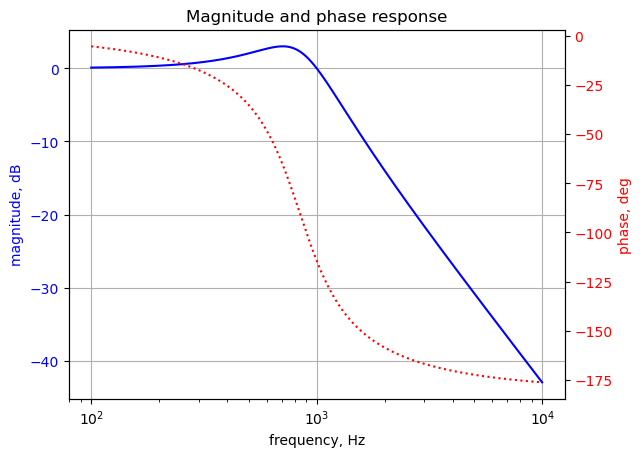

In [52]:
fig, ax1 = plt.subplots()
ax1.set_ylabel('magnitude, dB')
ax1.set_xlabel('frequency, Hz')

plt.semilogx(w/(2*np.pi), mag,'-b')    # Bode magnitude plot
ax1.set_ylabel('magnitude, dB',color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.tick_params(axis='y')
plt.grid()

# instantiate a second y-axes that shares the same x-axis
ax2 = ax1.twinx()
color = 'r'

plt.semilogx(w/(2*np.pi), phase,':',color=color)  # Bode phase plot

ax2.set_ylabel('phase, deg',color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Magnitude and phase response')
plt.savefig('eg2_mag_phase.png', bbox_inches='tight')
plt.show()

The poles and zeros of the transfer function can easly be obtained with the following code:

The pole-zero plot, also known as the s-plane plot, is a graphical representation of a transfer function, $H(s)$, where the locations of its poles and zeros are marked on the complex $s$-plane.  The zeros (roots of the numerator $N(s)$) are traditionally marked with a circle ($\circ$), and the poles (roots of the denominator $D(s)$) are marked with a cross ($\times$). The horizontal axis of the $s$-plane represents the real part ($\sigma$) which relates to the damping and transient response (decay or growth), while the vertical axis represents the imaginary part ($j\omega$) which relates to the oscillation frequency and sinusoidal steady-state response. This plot is a crucial visual aid because the relative positions of the poles and zeros immediately reveal key insights into the circuit's characteristics, such as its stability, natural frequencies, and how it will selectively amplify or attenuate signals at different frequencies, which is fundamental in filter design.

The proximity of a poles to the imaginary axis ($j\omega$ axis) in the pole-zero plot has a profound impact on the frequency response of the circuit. The closer a pole is to the $j\omega$ axis, the greater its influence on the magnitude of the transfer function $|H(j\omega)|$ for frequencies near the pole's imaginary part.  Specifically, a pole close to the axis corresponds to a higher Q-factor (quality factor), resulting in a sharp peak or resonance in the magnitude response curve at the pole's natural frequency, $\omega_d$ (which is the imaginary part of the pole). This means the circuit will selectively amplify signals at that specific frequency. Conversely, a pole located farther to the left (more negative real part $\sigma$) corresponds to a highly damped system, resulting in a much broader and flatter frequency response peak, or potentially no noticeable peak at all, as the system's energy quickly dissipates.

The poles and zeros of the preamp transfer function are plotted.

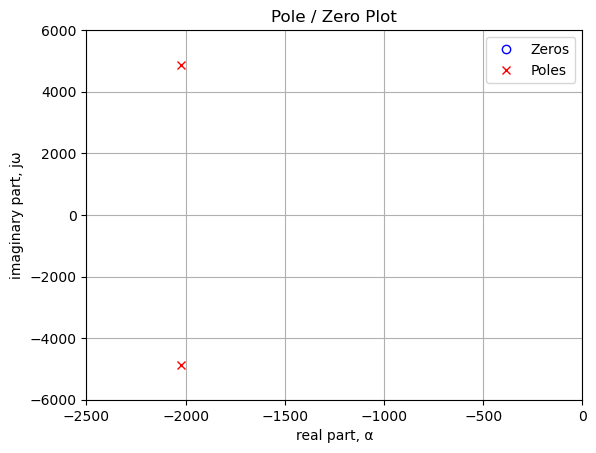

In [53]:
sys = signal.TransferFunction(a,b)

sys_zeros = np.roots(sys.num)
sys_poles = np.roots(sys.den)

plt.plot(np.real(sys_zeros), np.imag(sys_zeros), 'ob', markerfacecolor='none')
plt.plot(np.real(sys_poles), np.imag(sys_poles), 'xr')
plt.legend(['Zeros', 'Poles'], loc=0)
plt.title('Pole / Zero Plot')
plt.xlabel('real part, \u03B1')
plt.ylabel('imaginary part, j\u03C9')
plt.xlim((-2500,0))
plt.ylim((-6000,6000))
plt.grid()
plt.savefig('eg2_pole_zero.png', bbox_inches='tight')
plt.show()

Poles and zeros of the transfer function plotted on the complex plane. The units are in radian frequency.

The impulse response, $h(t)$, and the step response, $r(t)$, are two fundamental time-domain characteristics of a circuit defined by its transfer function, $H(s)$. The impulse response is the circuit's output when the input is an ideal Dirac delta function, $\delta(t)$, which is useful because $h(t)$ is the inverse Laplace transform of the transfer function itself: $h(t) = \mathcal{L}^{-1}\{H(s)\}$. It essentially reveals the natural, unforced behavior of the system. In contrast, the step response is the output when the input is a unit step function, $u(t)$ (a signal that jumps from zero to one at $t=0$), and it is related to the impulse response by integration: $r(t) = \int_0^t h(\tau) d\tau$.  Analyzing the step response is especially practical in circuit testing as it allows engineers to easily assess key performance metrics like rise time, settling time, overshoot, and steady-state error, all of which are crucial for evaluating the speed and quality of a circuit's transient behavior.

Rise time and settling time are key metrics derived from the step response that quantify the speed and convergence of a circuit's transient behavior.

- Rise Time ($t_r$): This is the time required for the step response to go from 10% of its final value to 90% of its final value. A shorter rise time indicates a faster circuit response. It is a measure of how quickly the system can react to a sudden change in input.
- Settling Time ($t_s$): This is the time required for the step response to reach and stay within a specified tolerance band around its final, steady-state value. The tolerance band is typically 2% or 5% of the final value. A common definition uses the 2% band. A shorter settling time indicates that the oscillations or transient effects damp out quickly, meaning the circuit stabilizes faster and is a measure of the circuit's overall speed and damping.

Both measurements are essential for evaluating system performance, where rise time reflects the initial speed, and settling time reflects the overall stability and convergence of the output.

Use the SciPy functions [impulse](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.impulse.html) and [step](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.step.html) to plot the impulse and step response of the system.

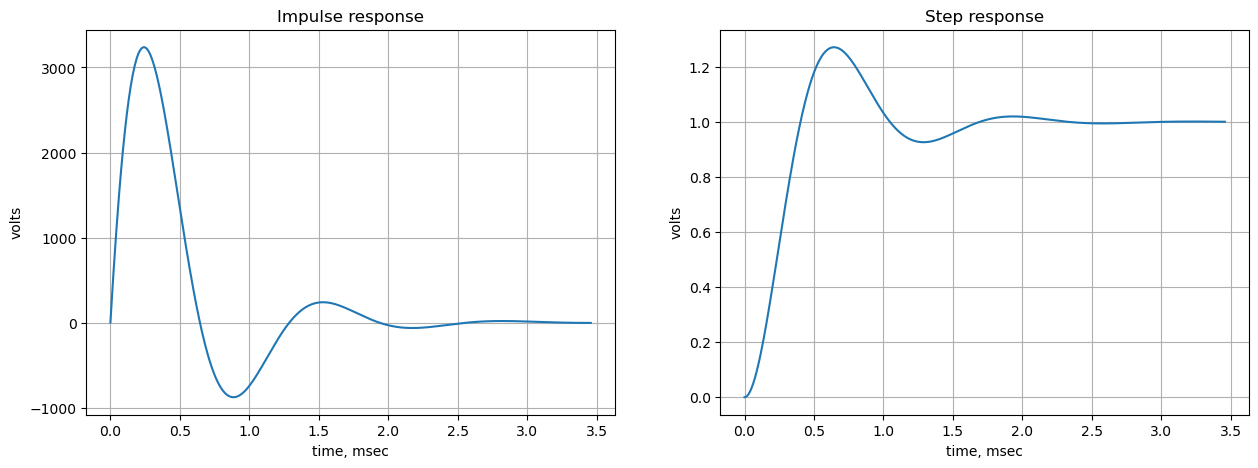

In [54]:
plt.subplots(1,2,figsize=(15, 5))

# using subplot function and creating
# plot one
plt.subplot(1, 2, 1)

# impulse response
t, y = signal.impulse(sys,N=500)
plt.plot(t/1e-3, y)
plt.title('Impulse response')
plt.ylabel('volts')
plt.xlabel('time, msec')
plt.grid()

# using subplot function and creating plot two
plt.subplot(1, 2, 2)

t, y = signal.step(sys,N=500)
plt.plot(t/1e-3, y)
plt.title('Step response')
plt.ylabel('volts')
plt.xlabel('time, msec')
plt.grid()

# show plot
plt.savefig('eg2_impulse_step.png', bbox_inches='tight')
plt.show()

### Example 3 - Transient Analysis
In this example the circuit in @fig-transient will be used to illustrate how Python and MNA can be used to analyize a circuit's transient behavior. Transient analysis evaluates how a cicuit responds over time to sudden, time-varying changes in its input signal, such as a square wave. Unlike steady-state AC analysis, which looks at how a circuit behaves under steady state conditions, transient analysis focuses on the temporary behavior that occurs immediately after a disturbance before the circuit settles into a stable state. This analysis is essential for identifying critical time-domain performance metrics such as propagation delay, rise and fall times, peak overshoot and the settling time of the filter, allowing engineers to ensure that the network does not introduce excessive ringing or signal distortion.

![Schematic for a low pass filter.](Transient_circuit.png){#fig-transient}

The circuit in @fig-transient is an elliptic low pass filter with a 1 Hz cut off and 3 dB of ripple in the pass band and 40 dB of attenuation in the stop band. Three dB of ripple in the pass band was designed in so that the transient response would have some ringing. A filter design tool by @MarkiMicrowave was used to design the filter. The netlist generated by LTSpice is pasted into the cell below and some edits were made to remove the inductor series resistance and the independent source, $V_1$, is set to a value of one.

The code below generates and displays the network equations.

In [55]:
net_list = '''
V1 1 0 1
R1 3 1 1
R2 2 0 1
L1 3 4 0.4925
L2 5 0 0.05081
C2 4 5 0.09876
L3 4 2 0.4925
'''

report, network_df, df2, A, X, Z = SymMNA.smna(net_list)

# Put matrices into SymPy 
X = Matrix(X)
Z = Matrix(Z)

NE_sym = Eq(A*X,Z)

# The symbols generated by the Python code are extracted by the SymPy function free_symbols
# and then declared as SymPy variables.
var(str(NE_sym.free_symbols).replace('{','').replace('}',''))

# built a dictionary of element values.
element_values = SymMNA.get_part_values(network_df)

# generate markdown text to display the network equations.
temp = ''
for i in range(len(X)):
    temp += '${:s}$<br>'.format(latex(Eq((A*X)[i:i+1][0],Z[i])))

Markdown(temp)

$I_{V1} + \frac{v_{1}}{R_{1}} - \frac{v_{3}}{R_{1}} = 0$<br>$- I_{L3} + \frac{v_{2}}{R_{2}} = 0$<br>$I_{L1} - \frac{v_{1}}{R_{1}} + \frac{v_{3}}{R_{1}} = 0$<br>$C_{2} s v_{4} - C_{2} s v_{5} - I_{L1} + I_{L3} = 0$<br>$- C_{2} s v_{4} + C_{2} s v_{5} + I_{L2} = 0$<br>$v_{1} = V_{1}$<br>$- I_{L1} L_{1} s + v_{3} - v_{4} = 0$<br>$- I_{L2} L_{2} s + v_{5} = 0$<br>$- I_{L3} L_{3} s - v_{2} + v_{4} = 0$<br>

As shown above MNA generated many equations and these would be difficult to solve by hand. Since the circuit is not too large, a symbolic solution can be easily obtained. The IPython magic command `%%time` is being used to get the length of time for the solution.

In [56]:
%%time
U_sym = solve(NE_sym,X)

CPU times: user 78 ms, sys: 82 µs, total: 78.1 ms
Wall time: 78.2 ms


Display the symbolic solutions for the node voltages and unknown currrents.

In [57]:
temp = ''
for i in U_sym.keys():
    temp += '${:s} = {:s}$<br>'.format(latex(i),latex(U_sym[i]))

Markdown(temp)

$v_{1} = V_{1}$<br>$v_{2} = \frac{C_{2} L_{2} R_{2} V_{1} s^{2} + R_{2} V_{1}}{C_{2} L_{1} L_{2} s^{3} + C_{2} L_{1} L_{3} s^{3} + C_{2} L_{1} R_{2} s^{2} + C_{2} L_{2} L_{3} s^{3} + C_{2} L_{2} R_{1} s^{2} + C_{2} L_{2} R_{2} s^{2} + C_{2} L_{3} R_{1} s^{2} + C_{2} R_{1} R_{2} s + L_{1} s + L_{3} s + R_{1} + R_{2}}$<br>$v_{3} = \frac{C_{2} L_{1} L_{2} V_{1} s^{3} + C_{2} L_{1} L_{3} V_{1} s^{3} + C_{2} L_{1} R_{2} V_{1} s^{2} + C_{2} L_{2} L_{3} V_{1} s^{3} + C_{2} L_{2} R_{2} V_{1} s^{2} + L_{1} V_{1} s + L_{3} V_{1} s + R_{2} V_{1}}{C_{2} L_{1} L_{2} s^{3} + C_{2} L_{1} L_{3} s^{3} + C_{2} L_{1} R_{2} s^{2} + C_{2} L_{2} L_{3} s^{3} + C_{2} L_{2} R_{1} s^{2} + C_{2} L_{2} R_{2} s^{2} + C_{2} L_{3} R_{1} s^{2} + C_{2} R_{1} R_{2} s + L_{1} s + L_{3} s + R_{1} + R_{2}}$<br>$v_{4} = \frac{C_{2} L_{2} L_{3} V_{1} s^{3} + C_{2} L_{2} R_{2} V_{1} s^{2} + L_{3} V_{1} s + R_{2} V_{1}}{C_{2} L_{1} L_{2} s^{3} + C_{2} L_{1} L_{3} s^{3} + C_{2} L_{1} R_{2} s^{2} + C_{2} L_{2} L_{3} s^{3} + C_{2} L_{2} R_{1} s^{2} + C_{2} L_{2} R_{2} s^{2} + C_{2} L_{3} R_{1} s^{2} + C_{2} R_{1} R_{2} s + L_{1} s + L_{3} s + R_{1} + R_{2}}$<br>$v_{5} = \frac{C_{2} L_{2} L_{3} V_{1} s^{3} + C_{2} L_{2} R_{2} V_{1} s^{2}}{C_{2} L_{1} L_{2} s^{3} + C_{2} L_{1} L_{3} s^{3} + C_{2} L_{1} R_{2} s^{2} + C_{2} L_{2} L_{3} s^{3} + C_{2} L_{2} R_{1} s^{2} + C_{2} L_{2} R_{2} s^{2} + C_{2} L_{3} R_{1} s^{2} + C_{2} R_{1} R_{2} s + L_{1} s + L_{3} s + R_{1} + R_{2}}$<br>$I_{V1} = \frac{- C_{2} L_{2} V_{1} s^{2} - C_{2} L_{3} V_{1} s^{2} - C_{2} R_{2} V_{1} s - V_{1}}{C_{2} L_{1} L_{2} s^{3} + C_{2} L_{1} L_{3} s^{3} + C_{2} L_{1} R_{2} s^{2} + C_{2} L_{2} L_{3} s^{3} + C_{2} L_{2} R_{1} s^{2} + C_{2} L_{2} R_{2} s^{2} + C_{2} L_{3} R_{1} s^{2} + C_{2} R_{1} R_{2} s + L_{1} s + L_{3} s + R_{1} + R_{2}}$<br>$I_{L1} = \frac{C_{2} L_{2} V_{1} s^{2} + C_{2} L_{3} V_{1} s^{2} + C_{2} R_{2} V_{1} s + V_{1}}{C_{2} L_{1} L_{2} s^{3} + C_{2} L_{1} L_{3} s^{3} + C_{2} L_{1} R_{2} s^{2} + C_{2} L_{2} L_{3} s^{3} + C_{2} L_{2} R_{1} s^{2} + C_{2} L_{2} R_{2} s^{2} + C_{2} L_{3} R_{1} s^{2} + C_{2} R_{1} R_{2} s + L_{1} s + L_{3} s + R_{1} + R_{2}}$<br>$I_{L2} = \frac{C_{2} L_{3} V_{1} s^{2} + C_{2} R_{2} V_{1} s}{C_{2} L_{1} L_{2} s^{3} + C_{2} L_{1} L_{3} s^{3} + C_{2} L_{1} R_{2} s^{2} + C_{2} L_{2} L_{3} s^{3} + C_{2} L_{2} R_{1} s^{2} + C_{2} L_{2} R_{2} s^{2} + C_{2} L_{3} R_{1} s^{2} + C_{2} R_{1} R_{2} s + L_{1} s + L_{3} s + R_{1} + R_{2}}$<br>$I_{L3} = \frac{C_{2} L_{2} V_{1} s^{2} + V_{1}}{C_{2} L_{1} L_{2} s^{3} + C_{2} L_{1} L_{3} s^{3} + C_{2} L_{1} R_{2} s^{2} + C_{2} L_{2} L_{3} s^{3} + C_{2} L_{2} R_{1} s^{2} + C_{2} L_{2} R_{2} s^{2} + C_{2} L_{3} R_{1} s^{2} + C_{2} R_{1} R_{2} s + L_{1} s + L_{3} s + R_{1} + R_{2}}$<br>

After substituting the numeric component values for the elements, a numerical solution for the note voltages can be obtained for the steady state condition.

In [58]:
NE = NE_sym.subs(element_values)

U = solve(NE,X)

The frequency response plot of the transfer function $H(s)=\frac{v_2}{v_1}$ is plotted with the code below.

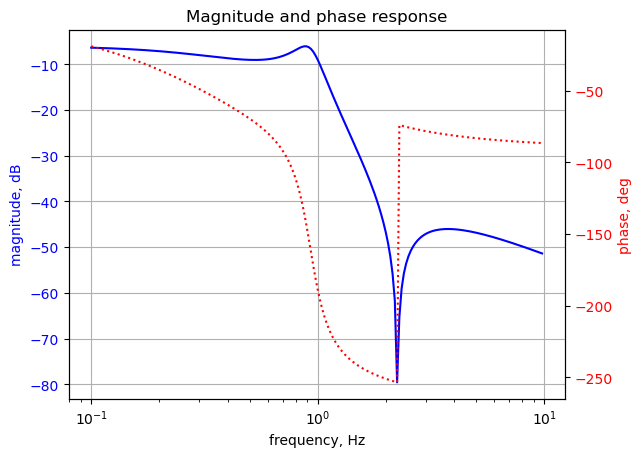

In [59]:
H = U[v2]/U[v1]

num, denom = fraction(H) #returns numerator and denominator

# convert symbolic to numpy polynomial
a = np.array(Poly(num, s).all_coeffs(), dtype=float)
b = np.array(Poly(denom, s).all_coeffs(), dtype=float)
system = (a, b)

x = np.logspace(-1, 1, 200, endpoint=False)*2*np.pi
w, mag, phase = signal.bode(system, w=x) # returns: rad/s, mag in dB, phase in deg

fig, ax1 = plt.subplots()
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_ylabel('magnitude, dB',color='b')
ax1.set_xlabel('frequency, Hz')

plt.semilogx(w/(2*np.pi), mag,'-b')    # Bode magnitude plot

ax1.tick_params(axis='y')
plt.grid()

# instantiate a second y-axes that shares the same x-axis
ax2 = ax1.twinx()
color = 'r'

plt.semilogx(w/(2*np.pi), phase,':',color=color)  # Bode phase plot

ax2.set_ylabel('phase, deg',color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Magnitude and phase response')
plt.savefig('eg3_mag_phase.png', bbox_inches='tight')
plt.show()

Using the expression for the steady state solution obtained above, we can use SciPy to plot the transient response to a square wave.

In [60]:
# convert symbolic to numpy polynomial
a = np.array(Poly(num, s).all_coeffs(), dtype=float)
b = np.array(Poly(denom, s).all_coeffs(), dtype=float)

The `scipy.signal.lsim` function is a versatile tool used in Python for simulating the time response of a continuous-time, linear time-invariant (LTI) system to an input signal.

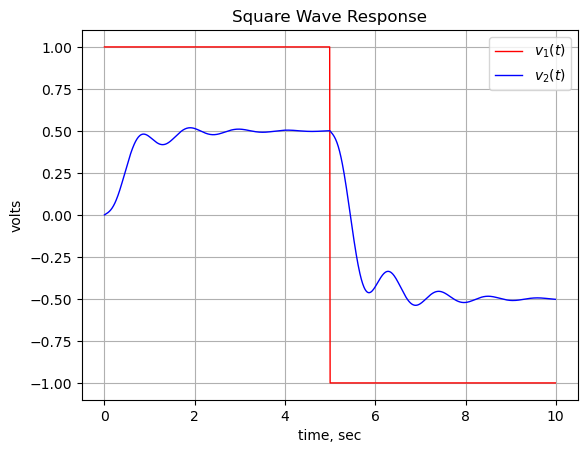

In [61]:
# Convert the expression to a continuous-time transfer function 
sys_tf = signal.TransferFunction(a,b)

# define the time interval and create a square wave
t = np.linspace(0, 10, 1000, endpoint=False)
ref_sqr_signal = signal.square(2*np.pi*1e-1*t, duty=0.5)

# call lsim to generate the response signal
ref_t_step, ref_y_step, ref_x_step = signal.lsim(sys_tf, U=ref_sqr_signal, T=t)

plt.plot(ref_t_step, ref_sqr_signal, 'r', alpha = 1.0, linewidth=1, label='$v_1(t)$')
plt.plot(ref_t_step, ref_y_step,'b', linewidth = 1.0, label='$v_2(t)$')
plt.title('Square Wave Response')
plt.ylabel('volts')
plt.xlabel('time, sec')
plt.grid()
plt.legend(loc='best')
plt.savefig('eg3_sqrwave.png', bbox_inches='tight')
# show plot
plt.show()

### Example 4 - Mutual Inductance
In this example the schematic in @fig-mutual_inductance models the essential elements of wireless power transfer system. $L_1$ and $L_2$ are two mutually coupled inductors seperated by a small air gap. $C_1$ and $C_2$ represent the capacitance in the circuit that causes the circuit to resonate at the desired frequency. $R_1$ represents the source inpedance of $V_1$ as well as any other losses on the transmitting side including the resistance in $L_1$. $R_2$ represents the load as well as any internal resistance of $L_2$. $K$ is the coupling coefficient and can be any number between -1 and +1. A value for $K$ would typically range from 0.1 to 0.45 for wireless charging of small devices and is depentend on seperation and alligment of the coils. There are phase dots shown on $L_1$ and $L_2$. Since the phase dots are orientated on the same ends of the coils, the voltage in each winding is in phase. 

![Mutual inductance schematic.](Wireless_power_transfer_v0.png){#fig-mutual_inductance}

In [62]:
ft=100e3
L1=5e-6
C1=((1/(ft*2*np.pi))**2)/L1
C1

In [63]:
C1=5e-7
ft = 1/(2*np.pi*np.sqrt(C1*L1))
ft

In [64]:
L2=47e-6
C2=((1/(ft*2*np.pi))**2)/L2
C2

In [65]:
C2=53e-9
fr = 1/(2*np.pi*np.sqrt(C2*L2))
fr

The netlist generated by LTSpice is pasted into the cell below and some edits were made to remove the inductor series resistance. 

In [66]:
net_list = '''
* Wireless_power_transfer_v0.asc
V1 1 0 1
R1 2 1 1
R2 4 0 100
C1 3 2 0.5e-6
C2 4 0 53e-9
L1 0 3 5e-6
L2 0 4 47e-6
K L1 L2 0.5
'''

report, network_df, df2, A, X, Z = SymMNA.smna(net_list)

# Put matrices into SymPy 
X = Matrix(X)
Z = Matrix(Z)

NE_sym = Eq(A*X,Z)

# The symbols generated by the Python code are extracted by the SymPy function free_symbols
# and then declared as SymPy variables.
var(str(NE_sym.free_symbols).replace('{','').replace('}',''))

K = symbols('K') # declare a symbol for the coupling coefficient

# built a dictionary of element values.
element_values = SymMNA.get_part_values(network_df)

# generate markdown text to display the network equations.
temp = ''
for i in range(len(X)):
    temp += '${:s}$<br>'.format(latex(Eq((A*X)[i:i+1][0],Z[i])))

Markdown(temp)

$I_{V1} + \frac{v_{1}}{R_{1}} - \frac{v_{2}}{R_{1}} = 0$<br>$- C_{1} s v_{3} + v_{2} \left(C_{1} s + \frac{1}{R_{1}}\right) - \frac{v_{1}}{R_{1}} = 0$<br>$- C_{1} s v_{2} + C_{1} s v_{3} - I_{L1} = 0$<br>$- I_{L2} + v_{4} \left(C_{2} s + \frac{1}{R_{2}}\right) = 0$<br>$v_{1} = V_{1}$<br>$- I_{L1} L_{1} s - I_{L2} M s - v_{3} = 0$<br>$- I_{L1} M s - I_{L2} L_{2} s - v_{4} = 0$<br>

These equations can be solved with SymPy.

In [67]:
%%time
U_sym = solve(NE_sym,X)

CPU times: user 63.4 ms, sys: 3.98 ms, total: 67.3 ms
Wall time: 66.8 ms


Display the symbolic solution

In [68]:
temp = ''
for i in U_sym.keys():
    temp += '${:s} = {:s}$<br>'.format(latex(i),latex(U_sym[i]))

Markdown(temp)

$v_{1} = V_{1}$<br>$v_{2} = \frac{C_{1} C_{2} L_{1} L_{2} R_{2} V_{1} s^{4} - C_{1} C_{2} M^{2} R_{2} V_{1} s^{4} + C_{1} L_{1} L_{2} V_{1} s^{3} + C_{1} L_{1} R_{2} V_{1} s^{2} - C_{1} M^{2} V_{1} s^{3} + C_{2} L_{2} R_{2} V_{1} s^{2} + L_{2} V_{1} s + R_{2} V_{1}}{C_{1} C_{2} L_{1} L_{2} R_{2} s^{4} + C_{1} C_{2} L_{2} R_{1} R_{2} s^{3} - C_{1} C_{2} M^{2} R_{2} s^{4} + C_{1} L_{1} L_{2} s^{3} + C_{1} L_{1} R_{2} s^{2} + C_{1} L_{2} R_{1} s^{2} - C_{1} M^{2} s^{3} + C_{1} R_{1} R_{2} s + C_{2} L_{2} R_{2} s^{2} + L_{2} s + R_{2}}$<br>$v_{3} = \frac{C_{1} C_{2} L_{1} L_{2} R_{2} V_{1} s^{4} - C_{1} C_{2} M^{2} R_{2} V_{1} s^{4} + C_{1} L_{1} L_{2} V_{1} s^{3} + C_{1} L_{1} R_{2} V_{1} s^{2} - C_{1} M^{2} V_{1} s^{3}}{C_{1} C_{2} L_{1} L_{2} R_{2} s^{4} + C_{1} C_{2} L_{2} R_{1} R_{2} s^{3} - C_{1} C_{2} M^{2} R_{2} s^{4} + C_{1} L_{1} L_{2} s^{3} + C_{1} L_{1} R_{2} s^{2} + C_{1} L_{2} R_{1} s^{2} - C_{1} M^{2} s^{3} + C_{1} R_{1} R_{2} s + C_{2} L_{2} R_{2} s^{2} + L_{2} s + R_{2}}$<br>$v_{4} = \frac{C_{1} M R_{2} V_{1} s^{2}}{C_{1} C_{2} L_{1} L_{2} R_{2} s^{4} + C_{1} C_{2} L_{2} R_{1} R_{2} s^{3} - C_{1} C_{2} M^{2} R_{2} s^{4} + C_{1} L_{1} L_{2} s^{3} + C_{1} L_{1} R_{2} s^{2} + C_{1} L_{2} R_{1} s^{2} - C_{1} M^{2} s^{3} + C_{1} R_{1} R_{2} s + C_{2} L_{2} R_{2} s^{2} + L_{2} s + R_{2}}$<br>$I_{V1} = \frac{- C_{1} C_{2} L_{2} R_{2} V_{1} s^{3} - C_{1} L_{2} V_{1} s^{2} - C_{1} R_{2} V_{1} s}{C_{1} C_{2} L_{1} L_{2} R_{2} s^{4} + C_{1} C_{2} L_{2} R_{1} R_{2} s^{3} - C_{1} C_{2} M^{2} R_{2} s^{4} + C_{1} L_{1} L_{2} s^{3} + C_{1} L_{1} R_{2} s^{2} + C_{1} L_{2} R_{1} s^{2} - C_{1} M^{2} s^{3} + C_{1} R_{1} R_{2} s + C_{2} L_{2} R_{2} s^{2} + L_{2} s + R_{2}}$<br>$I_{L1} = \frac{- C_{1} C_{2} L_{2} R_{2} V_{1} s^{3} - C_{1} L_{2} V_{1} s^{2} - C_{1} R_{2} V_{1} s}{C_{1} C_{2} L_{1} L_{2} R_{2} s^{4} + C_{1} C_{2} L_{2} R_{1} R_{2} s^{3} - C_{1} C_{2} M^{2} R_{2} s^{4} + C_{1} L_{1} L_{2} s^{3} + C_{1} L_{1} R_{2} s^{2} + C_{1} L_{2} R_{1} s^{2} - C_{1} M^{2} s^{3} + C_{1} R_{1} R_{2} s + C_{2} L_{2} R_{2} s^{2} + L_{2} s + R_{2}}$<br>$I_{L2} = \frac{C_{1} C_{2} M R_{2} V_{1} s^{3} + C_{1} M V_{1} s^{2}}{C_{1} C_{2} L_{1} L_{2} R_{2} s^{4} + C_{1} C_{2} L_{2} R_{1} R_{2} s^{3} - C_{1} C_{2} M^{2} R_{2} s^{4} + C_{1} L_{1} L_{2} s^{3} + C_{1} L_{1} R_{2} s^{2} + C_{1} L_{2} R_{1} s^{2} - C_{1} M^{2} s^{3} + C_{1} R_{1} R_{2} s + C_{2} L_{2} R_{2} s^{2} + L_{2} s + R_{2}}$<br>

The transfer function of the voltages on nodes $v_1$ and $v_2$ is shown below. As you can see, this is a fourth order system. Notice that the mutual inductance, $M$, has been introduced into the equations.

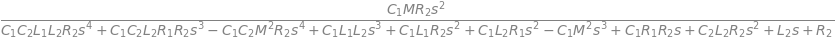

In [69]:
H_sym = U_sym[v4]/U_sym[v1]
H_sym

The value of $K$ can be from -1 to +1 to account for a negative phase relation. Phase dots are drawn on the schematic to indicate the relative direction of the windings. In LTspice the phase dots are associated with the negative terminal of the winding. The coupling constant and the mutual inductance are related by the equation: $K = \frac {M}{\sqrt{L_1 \times L_2}}$

Below, $M$ is calculated and added to the element value dictionary.

In [70]:
# calculate the mutual inductance from the coupling constant
element_values[M] = element_values[K]*np.sqrt(element_values[L1] *element_values[L2])
print('mutual inductance, M = {:.9f}'.format(element_values[M]))

mutual inductance, M = 0.000007665


After substituting the numeric component values for the elements, a numerical solution for the note voltages can be obtained for the steady state condition.

In [71]:
NE = NE_sym.subs(element_values)

U = solve(NE,X)

The frequency response plot of the transfer function $H(s)=\frac{v_2}{v_1}$ is plotted with the code below.

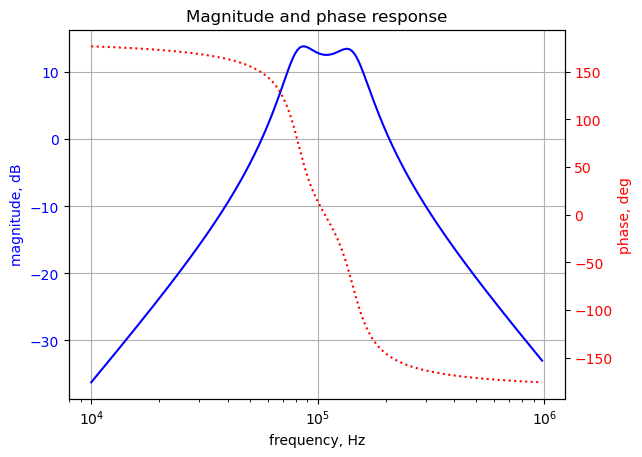

In [72]:
H = U[v4]/U[v1]
H_num, H_denom = fraction(H) #returns numerator and denominator

# convert symbolic to NumPy polynomial
a = np.array(Poly(H_num, s).all_coeffs(), dtype=float)
b = np.array(Poly(H_denom, s).all_coeffs(), dtype=float)

x = np.logspace(4, 6, 200, endpoint=False)*2*np.pi
w, mag, phase = signal.bode((a,b), w=x) # returns: rad/s, mag in dB, phase in deg

fig, ax1 = plt.subplots()
ax1.set_ylabel('magnitude, dB',color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xlabel('frequency, Hz')

plt.semilogx(w/(2*np.pi), mag,'-b')    # Bode magnitude plot

ax1.tick_params(axis='y')
plt.grid()

# instantiate a second y-axes that shares the same x-axis
ax2 = ax1.twinx()
color = 'r'

plt.semilogx(w/(2*np.pi), phase,':',color=color)  # Bode phase plot

ax2.set_ylabel('phase, deg',color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Magnitude and phase response')
plt.savefig('eg4_mag_phase.png', bbox_inches='tight')
plt.show()

Using the expression for the steady state solution obtained above, we can use SciPy to plot the transient response to a square wave.

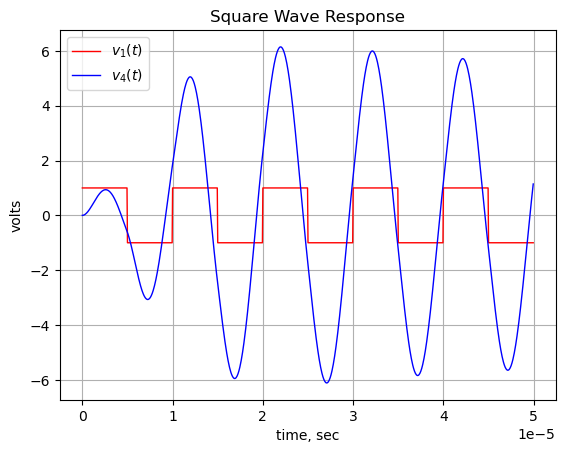

In [73]:
sys_tf = signal.TransferFunction(a,b)

# define the time interval and create a square wave
t = np.linspace(0, 0.00005, 1000, endpoint=False)
ref_sqr_signal = signal.square(2*np.pi*1e5*t, duty=0.5)

# call lsim to generate the response signal
ref_t_step, ref_y_step, ref_x_step = signal.lsim(sys_tf, U=ref_sqr_signal, T=t)

plt.plot(ref_t_step, ref_sqr_signal, 'r', alpha = 1.0, linewidth=1, label='$v_1(t)$')
plt.plot(ref_t_step, ref_y_step,'b', linewidth = 1.0, label='$v_4(t)$')
plt.title('Square Wave Response')
plt.ylabel('volts')
plt.xlabel('time, sec')
plt.grid()
plt.legend(loc='best')
plt.savefig('eg4_sqrwave.png', bbox_inches='tight')
# show plot
plt.show()

### Example 5 - Initial Conditions
In this example, the initial conditions for capacitors and inductors are explored. Initial conditions refer to the state of the energy storing elements, capacitor and inductors, at $t = 0$, the point in time where the analysis starts. In s-domain analysis, the initial conditions are included in the analysis by using auxiliary sources in the transformed models of the capacitors and inductors. 

Unless the initial conditions are specified, the voltage on the capacitors and the current through the inductors are assumed to be zero. Initial conditions for capacitors and inductors are essential in transient circuit analysis as they represent the energy stored in these components immediately prior to a change in the circuit, such as a switch opening or closing at time $t=0$. 

Mathematically, this is expressed as $v_C(0^-) = 0$ then $v_C(0) = V_{ic}$ and $i_L(0^-) = 0$ then $i_L(0)=I_{ic}$, where $0^-$ is the first instant of time to the left of $t=0$. Some engineering text books use $v_C(0^-) = v_C(0)$ and $i_L(0^-) = i_L(0)$, others use $v_C(0) = v_C(0^+)$ and $i_L(0) = i_L(0^+)$. So depending on which text book is consulted, there can be different ways of describing the value of the initial conditions at the time origin. Some of these inconsistencies are explored in @Lundberg2007.

#### Initial Capacitor Voltage
In the analysis presented in this example, capacitors are assumed to have an initial condition described in terms of an initial voltage across its terminals. This is modeled with a series DC step-voltage source of value $\frac{v_C(0^-)}{s}$. The added series voltage source is the s-domain abstraction of the initial energy stored in the capacitor expressed in terms of voltage. The schematic of this is shown in @fig-Cap_Ind_init_cond_model_v0, where the capacitor is replaced by:  

$\underbrace{\frac{1}{Cs}}_{\text{Impedance}} + \underbrace{\frac{v_C(0^-)}{s}}_{\text{Series voltage source}}$

#### Initial Inductor Current
Inductors in the network that have initial conditions, have initial conditions described in terms of an initial current flowing in the inductor at $t=0$. This is modeled by a DC step-current source of value $\frac{i_L(0^-)}{s}$. The parallel current source is the s-domain abstraction of the inductor's internal magnetic field. The schematic of this is shown in @fig-Cap_Ind_init_cond_model_v0, where the inductor is replaced by:  

$\underbrace{{Ls}}_{\text{Impedance}}  \parallel \underbrace{\frac{i_L(0^-)}{s}}_{\text{Parallel current source}}$

@fig-initial_conditions_example_4_v0_combined shows the model for initial conditions used in this chapter for capacitors and inductors. Part (a) Shows the orginal circuit where the initial voltage on $C_1$ and the initial current in $L_1$ are modeled by the elements shown in part (b). Although it is possible to describe initial conditions for capacitors in terms of current, I think it is more intuitive to think about a capacitor as having an initial voltage as the initial condition at $t=0$. The polarity of $V$, can be changed either by changing the orientation of the symbol in the schematic before the netlist is generated or by changing the sign of the value of the initial voltage. The initial condition for inductors can also be described in terms of an initial voltage, I think it is more natural to describe the initial condition in terms of current present in the inductor at $t=0$. The direction of the arrow in the current symbol in the LTSpice schematic can be confusing since the convention used is that the positive direction is out of node 1 in the figure below, which is opposite to the direction of the arrow on the current symbol.   

![The orginal circuit is shown in (a). (b) shows the initial conditions modeled by adding independent sources to the element branches.](Initial_conditions_example_4_v0_combined.png){#fig-initial_conditions_example_4_v0_combined}  
<!--
Typst  
#figure(
  image("Initial_conditions_example_4_v0_combined.png", width: 50%),
  caption : [This .]
) <example_5_sch_1>
-->

The schematic in @fig-Initial_conditions_example_3_v1 has seven branches and four nodes. $V_1$ represents the initial voltage on $C_2$ and $I_1$ represents the initial current in $L_2$.

![Initial conditions test circuit.](Initial_conditions_example_4_v1.png){#fig-Initial_conditions_example_4_v1}
<!--
Typst  
#figure(
  image("Initial_conditions_example_4_v1.png", width: 50%),
  caption : [This .]
) <example_5_sch_2>
-->

The circuit was drawn using LTSpice and the netlist was pasted into the code.

The code below assembles the network equations from the MNA matrices and displays the equations.

In [74]:
Example_3_net_list = '''
* Initial_conditions_example_4_v1.asc
L1 1 2 1e-3
C1 1 3 1e-6
R1 2 0 10
V1 3 0 1
I1 2 1 1
'''

report, network_df, i_unk_df, A, X, Z = SymMNA.smna(Example_3_net_list)

# Put matrices into SymPy 
X = Matrix(X)
Z = Matrix(Z)

# put the matrices into equation form 
NE_sym = Eq(A*X,Z)

# free symbols are entered as SymPy variables
var(str(NE_sym.free_symbols).replace('{','').replace('}',''))

# the element values are put into a dictionary
element_values = SymMNA.get_part_values(network_df) # get element values from netlist

# display the equations
temp = ''
for i in range(shape(NE_sym.lhs)[0]):
    temp += '${:s} = {:s}$<br>'.format(latex(NE_sym.rhs[i]),latex(NE_sym.lhs[i]))
Markdown(temp)

$I_{1} = C_{1} s v_{1} - C_{1} s v_{3} + I_{L1}$<br>$- I_{1} = - I_{L1} + \frac{v_{2}}{R_{1}}$<br>$0 = - C_{1} s v_{1} + C_{1} s v_{3} + I_{V1}$<br>$V_{1} = v_{3}$<br>$0 = - I_{L1} L_{1} s + v_{1} - v_{2}$<br>

The initial conditions for $C_2$ and $L_2$ are set by $V_1$ and $I_1$. A step function with values of 1 is used for $V_1$ and $I_1$.

In [75]:
element_values[V1] = element_values[V1]/s
element_values[I1] = element_values[I1]/s
NE_ic = NE_sym.subs(element_values)

# display the equations
temp = ''
for i in range(shape(NE_ic.lhs)[0]):
    temp += '${:s} = {:s}$<br>'.format(latex(NE_ic.rhs[i]),latex(NE_ic.lhs[i]))
Markdown(temp)

$\frac{1.0}{s} = I_{L1} + 1.0 \cdot 10^{-6} s v_{1} - 1.0 \cdot 10^{-6} s v_{3}$<br>$- \frac{1.0}{s} = - I_{L1} + 0.1 v_{2}$<br>$0 = I_{V1} - 1.0 \cdot 10^{-6} s v_{1} + 1.0 \cdot 10^{-6} s v_{3}$<br>$\frac{1.0}{s} = v_{3}$<br>$0 = - 0.001 I_{L1} s + v_{1} - v_{2}$<br>

Solve the network equations and display the results.

In [76]:
U_ic = solve(NE_ic,X)

temp = ''
for i in U_ic.keys():
    temp += '${:s} = {:s}$<br>'.format(latex(i),latex(U_ic[i]))

Markdown(temp)

$v_{1} = \frac{s + 1010000.0}{s^{2} + 10000.0 s + 1000000000.0}$<br>$v_{2} = \frac{10000.0 - 10.0 s}{s^{2} + 10000.0 s + 1000000000.0}$<br>$v_{3} = \frac{1}{s}$<br>$I_{V1} = \frac{s - 1000.0}{s^{2} + 10000.0 s + 1000000000.0}$<br>$I_{L1} = \frac{11000.0 s + 1000000000.0}{s^{3} + 10000.0 s^{2} + 1000000000.0 s}$<br>

The voltage at node 1 is:

In [77]:
node_1_voltage_s = U_ic[v1].nsimplify()
node_1_voltage_s

Declare the symbol $t$ to be used as the time variable.

In [78]:
t = symbols('t',positive=True)  # t > 0

Find the inverse Laplace transform using the SymPy function, `inverse_laplace_transform`.

In [79]:
%%time
node_1_voltage_t = inverse_laplace_transform(node_1_voltage_s, s, t)

CPU times: user 8.16 s, sys: 7.76 ms, total: 8.17 s
Wall time: 8.17 s


In [80]:
node_1_voltage_t

Use lambdify to generate a function of time.

In [81]:
func_node_1_voltage_t = lambdify(t, node_1_voltage_t) 

The inverse Laplace is obtained for node voltage 2 with the following code.  

In [82]:
node_2_voltage_s = U_ic[v2].nsimplify()
node_2_voltage_s

In [83]:
%%time
node_2_voltage_t = inverse_laplace_transform(node_2_voltage_s, s, t)

CPU times: user 7.89 s, sys: 7.77 ms, total: 7.9 s
Wall time: 7.92 s


In [84]:
node_2_voltage_t

Use lambdify to generate a function of time.

In [85]:
func_node_2_voltage_t = lambdify(t, node_2_voltage_t) 

In [86]:
%%time
V1_current_s = U_ic[I_V1].nsimplify()

CPU times: user 22.9 ms, sys: 0 ns, total: 22.9 ms
Wall time: 22.6 ms


In [87]:
V1_current_s

In [88]:
%%time
V1_current_t = inverse_laplace_transform(V1_current_s, s, t)

CPU times: user 7.39 s, sys: 0 ns, total: 7.39 s
Wall time: 7.39 s


In [89]:
V1_current_t

Use lambdify to generate a function of time.

In [90]:
func_V1_current_t = lambdify(t, V1_current_t) 

The frequeny domain expression for the current in $L_1$ is shown below. 

In [91]:
L1_current_s = U_ic[I_L1].nsimplify()
L1_current_s

Since the current for $L_1$ has a third order demoninator, using the standard SymPy inverse Laplace transform function will take a long time, if ever, to obtain the inverse function, we insted obtain the inverse transform by find the partial fraction expansion of the expression. The code shown below was inspired by the answer given by _Davide_sd_ for the question in @zorka5.

In [92]:
n, d = fraction(L1_current_s) # get the numerator and denominator for the expression.

n = n.expand() # expand the numerator to get the individual additive terms

In [93]:
# Each of the numerator terms can be put over the common denominator.
if len(Add.make_args(n)) > 1: # check for the number of additive terms in the numerator
    terms = [a / d for a in n.args]
else:
    terms = [n/d]

In [94]:
terms

The following code processes each of the terms obtained above. 
- the SciPy function [residue](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.residue.html) is used to get the residues and poles of the partial-fraction expansion
- r: Residues corresponding to the poles. For repeated poles, the residues are ordered to correspond to ascending by power fractions.
- p: Poles ordered by magnitude in ascending order.
- k: Coefficients of the direct polynomial term.
When computing the inverse Laplace transform, the Coefficients (k) are ignored since these transform to a Dirac delta function, $\delta (t)$ and don't need to be plotted.

In [95]:
N = []
for p1 in terms:

    # use the SciPy residue function to get the partial-fraction expansion residues and poles
    n, d = fraction(p1)
    cn = Poly(n, s).all_coeffs()
    cd = Poly(d, s).all_coeffs()
    r, p, k = signal.residue(cn, cd, tol=0.001, rtype='avg')

    # build a symbolic expression for each of the residues and find the inverse Laplace of each one
    z = 0
    for i in range(len(r)):
        m = (r[i]/(s-p[i]))
        z += inverse_laplace_transform(m, s, t)

    N.append(z)

The inverse Laplace for each of the terms is shown below.

In [96]:
N

Use lambdify to generate a function of time.

In [97]:
# Each of these terms can be converted to a function using SymPy's [lambdify](https://docs.sympy.org/latest/modules/utilities/lambdify.html) function.
# Define the values for the x-axis of the plot and put into an array for plotting.
x = np.linspace(0, 1e-3, 2000, endpoint=True)
func_L1_current_t = np.zeros(len(x),dtype = complex)
for p in N:
    func_L1_current_t += lambdify(t, p)(x)

Plot the voltages and currents.

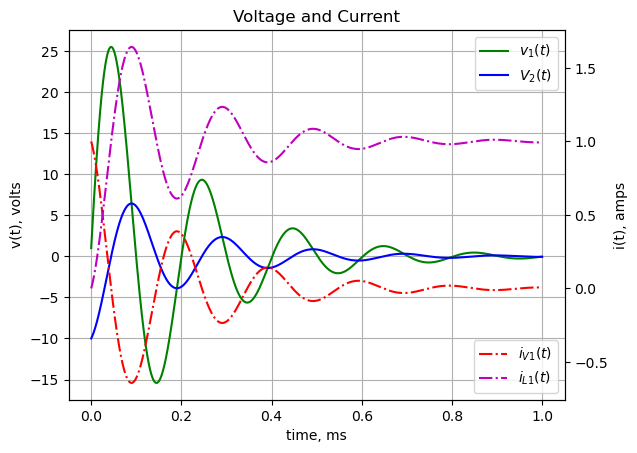

In [98]:
fig, ax1 = plt.subplots()
ax1.set_ylabel('v(t), volts')
ax1.set_xlabel('time, ms')

# plot voltages
plt.plot(x*1000, func_node_1_voltage_t(x),'-g',label='$v_1(t)$')
plt.plot(x*1000, func_node_2_voltage_t(x),'-b',label='$V_2(t)$')

ax1.tick_params(axis='y')
plt.legend(loc='upper right')
plt.grid()

# instantiate a second y-axes that shares the same x-axis
ax2 = ax1.twinx()
color = 'k'

# plot currents
plt.plot(x*1000, func_V1_current_t(x),'-.r',label='$i_{V1}(t)$')
plt.plot(x*1000, np.real(func_L1_current_t),'-.m',label='$i_{L1}(t)$')

ax2.set_ylabel('i(t), amps',color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.legend(loc='lower right')
plt.title('Voltage and Current')
plt.savefig('eg5_step.png', bbox_inches='tight')
plt.show()

<!--
Typst  
#figure(
  image("??.png", width: 50%),
  caption : [This .]
) <example_5_plot>
-->
Notice that the plot for $i_{L1}(t)$ has an offset equal to the value of $I_1$. However, this is not what we would expect when $L_1$ has an initial condition of $i_{L_1}=1$, since $i(t)$ should $\to 0$, due to the losses in the circuit from $R_1$. Using $\frac{I_1}{s}$ to represent the initial conditions in $L_1$ produces correct node voltages, but the solution for the current in $L_1$ needs to be adjusted. In this example, offsetting the current in the inductor by -1 would correct the result at $t=0$ and as $t \to \infty$. 

### Example 6 - Controlled Sources
The final example is the circuit shown in @fig-controlled_sources_example_v0. This circuit has a varity of dependent and independent sources. There are 13 branches in the circuit and eight nodes in the circuit. The circuit has six resistors, one capacitor and one inductor along with two independent voltage sources and one independent current source.

$V_1$ is an independent AC voltage source, $I_1$ is an independent DC current source, $G$ is a voltage controlled current source (VCCS) and $H$ is a current controlled voltage source (CCVS), with the controlling current determined by the current in $V_2$, which has a voltage value of zero.

The circuit analysis involves a two-step process based on the superposition theorem.

Step 1: The DC operating point of the circuit is calculated by setting:
- DC voltage and current sources are set to their specified values.
- All independent AC sources are set to zero.
- The Laplace variable, $s=j \omega$ is zero since $\omega=0$.

Step 2: The frequency-Domain AC Analysis is calculated by setting:
- All independent DC sources are set to zero. They set the operating point in Step 1, but contribute zero signal amplitude in Step 2.
- The AC source generates a unit sinusoidal signal at the frequencies specified when $\omega$ is assigned a value.

![This schematic contains a variety of sources.](Controlled_sources_example_v0.png){#fig-example_6_sch}
<!--
Typst  
#figure(
  image("Controlled_sources_example_v0.png", width: 50%),
  caption : [This schematic contains a variety of sources.]
) <example_6_sch>
-->

In [32]:
net_list = '''
* Controlled_sources_example_v0.asc
I1 6 1 3
G 6 4 3 7 1
H 7 0 V2 3
V1 1 5 10
C1 3 5 0.1
L1 6 8 4
R1 2 4 5
R2 5 7 3
R3 6 5 9
V2 1 2 0
R5 8 0 1
R7 1 3 7
R8 1 6 2
'''

# generate the MNA matrices. 
report, network_df, i_unk_df, A, X, Z = SymMNA.smna(net_list)

# Put matrices into SymPy 
X = Matrix(X)
Z = Matrix(Z)

# assemble the system of equations
NE_sym = Eq(A*X,Z)

# turn the free symbols into SymPy variables.
var(str(NE_sym.free_symbols).replace('{','').replace('}',''))

# display the network equations
temp = ''
for i in range(len(X)):
    temp += '${:s}$<br>'.format(latex(Eq((A*X)[i:i+1][0],Z[i])))

Markdown(temp)

$I_{V1} + I_{V2} + v_{1} \cdot \left(\frac{1}{R_{8}} + \frac{1}{R_{7}}\right) - \frac{v_{6}}{R_{8}} - \frac{v_{3}}{R_{7}} = I_{1}$<br>$- I_{V2} + \frac{v_{2}}{R_{1}} - \frac{v_{4}}{R_{1}} = 0$<br>$- C_{1} s v_{5} + v_{3} \left(C_{1} s + \frac{1}{R_{7}}\right) - \frac{v_{1}}{R_{7}} = 0$<br>$- g v_{3} + g v_{7} - \frac{v_{2}}{R_{1}} + \frac{v_{4}}{R_{1}} = 0$<br>$- C_{1} s v_{3} - I_{V1} + v_{5} \left(C_{1} s + \frac{1}{R_{3}} + \frac{1}{R_{2}}\right) - \frac{v_{6}}{R_{3}} - \frac{v_{7}}{R_{2}} = 0$<br>$I_{L1} + g v_{3} - g v_{7} + v_{6} \cdot \left(\frac{1}{R_{8}} + \frac{1}{R_{3}}\right) - \frac{v_{1}}{R_{8}} - \frac{v_{5}}{R_{3}} = - I_{1}$<br>$I_{H} - \frac{v_{5}}{R_{2}} + \frac{v_{7}}{R_{2}} = 0$<br>$- I_{L1} + \frac{v_{8}}{R_{5}} = 0$<br>$v_{1} - v_{5} = V_{1}$<br>$v_{1} - v_{2} = V_{2}$<br>$- I_{V2} h + v_{7} = 0$<br>$- I_{L1} L_{1} s + v_{6} - v_{8} = 0$<br>

Notice in the equations above, the gain terms for the VCCS, $G$, and CCVS, $H$, are written as lower case $g$ and $h$.

In [33]:
# build equations for Typst, need to add subscript numbers '_'
temp = '$'
for i in range(shape(NE_sym.lhs)[0]):
    temp += '{:s} &= {:s} % '.format(str(NE_sym.rhs[i]),str(NE_sym.lhs[i]))
temp += '$ <ex5_network_equations>'
temp

'$I1 &= I_V1 + I_V2 + v1*(1/R8 + 1/R7) - v6/R8 - v3/R7 % 0 &= -I_V2 + v2/R1 - v4/R1 % 0 &= -C1*s*v5 + v3*(C1*s + 1/R7) - v1/R7 % 0 &= -g*v3 + g*v7 - v2/R1 + v4/R1 % 0 &= -C1*s*v3 - I_V1 + v5*(C1*s + 1/R3 + 1/R2) - v6/R3 - v7/R2 % -I1 &= I_L1 + g*v3 - g*v7 + v6*(1/R8 + 1/R3) - v1/R8 - v5/R3 % 0 &= I_H - v5/R2 + v7/R2 % 0 &= -I_L1 + v8/R5 % V1 &= v1 - v5 % V2 &= v1 - v2 % 0 &= -I_V2*h + v7 % 0 &= -I_L1*L1*s + v6 - v8 % $ <ex5_equ_1>'

Remove `*`, replace `%` with `\`, subscript most variables.

In [34]:
temp = temp.replace('*','').replace('%','\\n')
temp

'$I1 &= I_V1 + I_V2 + v1(1/R8 + 1/R7) - v6/R8 - v3/R7 \\n 0 &= -I_V2 + v2/R1 - v4/R1 \\n 0 &= -C1sv5 + v3(C1s + 1/R7) - v1/R7 \\n 0 &= -gv3 + gv7 - v2/R1 + v4/R1 \\n 0 &= -C1sv3 - I_V1 + v5(C1s + 1/R3 + 1/R2) - v6/R3 - v7/R2 \\n -I1 &= I_L1 + gv3 - gv7 + v6(1/R8 + 1/R3) - v1/R8 - v5/R3 \\n 0 &= I_H - v5/R2 + v7/R2 \\n 0 &= -I_L1 + v8/R5 \\n V1 &= v1 - v5 \\n V2 &= v1 - v2 \\n 0 &= -I_V2h + v7 \\n 0 &= -I_L1L1s + v6 - v8 \\n $ <ex5_equ_1>'

Apply subscripts to most variables, some manual editing will be required.

In [35]:
pattern = r'([a-zA-Z])(\d)'
replacement = r'\1_\2'
new_string = re.sub(pattern, replacement, temp)
new_string

'$I_1 &= I_V_1 + I_V_2 + v_1(1/R_8 + 1/R_7) - v_6/R_8 - v_3/R_7 \\n 0 &= -I_V_2 + v_2/R_1 - v_4/R_1 \\n 0 &= -C_1sv_5 + v_3(C_1s + 1/R_7) - v_1/R_7 \\n 0 &= -gv_3 + gv_7 - v_2/R_1 + v_4/R_1 \\n 0 &= -C_1sv_3 - I_V_1 + v_5(C_1s + 1/R_3 + 1/R_2) - v_6/R_3 - v_7/R_2 \\n -I_1 &= I_L_1 + gv_3 - gv_7 + v_6(1/R_8 + 1/R_3) - v_1/R_8 - v_5/R_3 \\n 0 &= I_H - v_5/R_2 + v_7/R_2 \\n 0 &= -I_L_1 + v_8/R_5 \\n V_1 &= v_1 - v_5 \\n V_2 &= v_1 - v_2 \\n 0 &= -I_V_2h + v_7 \\n 0 &= -I_L_1L_1s + v_6 - v_8 \\n $ <ex_5_equ_1>'

Manually edit this string to fix any problems and copy paste into Typst.

Now that we have the network equations in symbolic form we can use SymPy to solve the equations.  
Use the `solve` function to obtain the expressions for the node voltages and unknown currents. The node voltages in symbolic form are displayed below.

Although, obtaining the solution is easy with SymPy, the symbolic results are long and not that useful. 

In [7]:
%%time
U_sym = solve(NE_sym,X)

CPU times: user 1.41 s, sys: 2.53 ms, total: 1.41 s
Wall time: 1.42 s


In [8]:
temp = ''
for i in U_sym.keys():
    temp += '${:s} = {:s}$<br>'.format(latex(i),latex(U_sym[i]))

Markdown(temp)

$v_{1} = \frac{- C_{1} I_{1} R_{2} R_{3} R_{7} R_{8} g h s + C_{1} I_{1} R_{2} R_{3} R_{7} R_{8} s + C_{1} L_{1} R_{3} R_{7} V_{1} s^{2} + C_{1} L_{1} R_{7} R_{8} V_{1} s^{2} - C_{1} R_{2} R_{3} R_{7} R_{8} V_{1} g s - C_{1} R_{2} R_{7} R_{8} V_{1} g h s + C_{1} R_{2} R_{7} R_{8} V_{1} s + C_{1} R_{3} R_{5} R_{7} V_{1} s + C_{1} R_{3} R_{7} R_{8} V_{1} s + C_{1} R_{5} R_{7} R_{8} V_{1} s - I_{1} R_{2} R_{3} R_{8} g h + I_{1} R_{2} R_{3} R_{8} - L_{1} R_{3} V_{1} g h s + L_{1} R_{3} V_{1} s - L_{1} R_{8} V_{1} g h s + L_{1} R_{8} V_{1} s - R_{2} R_{8} V_{1} g h + R_{2} R_{8} V_{1} - R_{3} R_{5} V_{1} g h + R_{3} R_{5} V_{1} - R_{3} R_{8} V_{1} g h + R_{3} R_{8} V_{1} - R_{5} R_{8} V_{1} g h + R_{5} R_{8} V_{1}}{C_{1} L_{1} R_{3} R_{7} s^{2} + C_{1} L_{1} R_{7} R_{8} s^{2} - C_{1} R_{2} R_{3} R_{7} R_{8} g s - C_{1} R_{2} R_{3} R_{7} g h s + C_{1} R_{2} R_{3} R_{7} s - C_{1} R_{2} R_{7} R_{8} g h s + C_{1} R_{2} R_{7} R_{8} s + C_{1} R_{3} R_{5} R_{7} s + C_{1} R_{3} R_{7} R_{8} s + C_{1} R_{5} R_{7} R_{8} s + L_{1} R_{3} s + L_{1} R_{8} s - R_{2} R_{3} R_{8} g - R_{2} R_{3} g h + R_{2} R_{3} - R_{2} R_{8} g h + R_{2} R_{8} + R_{3} R_{5} + R_{3} R_{8} + R_{5} R_{8}}$<br>$v_{2} = \frac{- C_{1} I_{1} R_{2} R_{3} R_{7} R_{8} g h s + C_{1} I_{1} R_{2} R_{3} R_{7} R_{8} s + C_{1} L_{1} R_{3} R_{7} V_{1} s^{2} - C_{1} L_{1} R_{3} R_{7} V_{2} s^{2} + C_{1} L_{1} R_{7} R_{8} V_{1} s^{2} - C_{1} L_{1} R_{7} R_{8} V_{2} s^{2} - C_{1} R_{2} R_{3} R_{7} R_{8} V_{1} g s + C_{1} R_{2} R_{3} R_{7} R_{8} V_{2} g s + C_{1} R_{2} R_{3} R_{7} V_{2} g h s - C_{1} R_{2} R_{3} R_{7} V_{2} s - C_{1} R_{2} R_{7} R_{8} V_{1} g h s + C_{1} R_{2} R_{7} R_{8} V_{1} s + C_{1} R_{2} R_{7} R_{8} V_{2} g h s - C_{1} R_{2} R_{7} R_{8} V_{2} s + C_{1} R_{3} R_{5} R_{7} V_{1} s - C_{1} R_{3} R_{5} R_{7} V_{2} s + C_{1} R_{3} R_{7} R_{8} V_{1} s - C_{1} R_{3} R_{7} R_{8} V_{2} s + C_{1} R_{5} R_{7} R_{8} V_{1} s - C_{1} R_{5} R_{7} R_{8} V_{2} s - I_{1} R_{2} R_{3} R_{8} g h + I_{1} R_{2} R_{3} R_{8} - L_{1} R_{3} V_{1} g h s + L_{1} R_{3} V_{1} s - L_{1} R_{3} V_{2} s - L_{1} R_{8} V_{1} g h s + L_{1} R_{8} V_{1} s - L_{1} R_{8} V_{2} s + R_{2} R_{3} R_{8} V_{2} g + R_{2} R_{3} V_{2} g h - R_{2} R_{3} V_{2} - R_{2} R_{8} V_{1} g h + R_{2} R_{8} V_{1} + R_{2} R_{8} V_{2} g h - R_{2} R_{8} V_{2} - R_{3} R_{5} V_{1} g h + R_{3} R_{5} V_{1} - R_{3} R_{5} V_{2} - R_{3} R_{8} V_{1} g h + R_{3} R_{8} V_{1} - R_{3} R_{8} V_{2} - R_{5} R_{8} V_{1} g h + R_{5} R_{8} V_{1} - R_{5} R_{8} V_{2}}{C_{1} L_{1} R_{3} R_{7} s^{2} + C_{1} L_{1} R_{7} R_{8} s^{2} - C_{1} R_{2} R_{3} R_{7} R_{8} g s - C_{1} R_{2} R_{3} R_{7} g h s + C_{1} R_{2} R_{3} R_{7} s - C_{1} R_{2} R_{7} R_{8} g h s + C_{1} R_{2} R_{7} R_{8} s + C_{1} R_{3} R_{5} R_{7} s + C_{1} R_{3} R_{7} R_{8} s + C_{1} R_{5} R_{7} R_{8} s + L_{1} R_{3} s + L_{1} R_{8} s - R_{2} R_{3} R_{8} g - R_{2} R_{3} g h + R_{2} R_{3} - R_{2} R_{8} g h + R_{2} R_{8} + R_{3} R_{5} + R_{3} R_{8} + R_{5} R_{8}}$<br>$v_{3} = \frac{- C_{1} I_{1} R_{2} R_{3} R_{7} R_{8} g h s + C_{1} I_{1} R_{2} R_{3} R_{7} R_{8} s + C_{1} R_{2} R_{3} R_{7} V_{1} g h s - C_{1} R_{2} R_{3} R_{7} V_{1} s - I_{1} R_{2} R_{3} R_{8} g h + I_{1} R_{2} R_{3} R_{8} - L_{1} R_{3} V_{1} g h s + L_{1} R_{3} V_{1} s - L_{1} R_{8} V_{1} g h s + L_{1} R_{8} V_{1} s - R_{2} R_{8} V_{1} g h + R_{2} R_{8} V_{1} - R_{3} R_{5} V_{1} g h + R_{3} R_{5} V_{1} - R_{3} R_{8} V_{1} g h + R_{3} R_{8} V_{1} - R_{5} R_{8} V_{1} g h + R_{5} R_{8} V_{1}}{C_{1} L_{1} R_{3} R_{7} s^{2} + C_{1} L_{1} R_{7} R_{8} s^{2} - C_{1} R_{2} R_{3} R_{7} R_{8} g s - C_{1} R_{2} R_{3} R_{7} g h s + C_{1} R_{2} R_{3} R_{7} s - C_{1} R_{2} R_{7} R_{8} g h s + C_{1} R_{2} R_{7} R_{8} s + C_{1} R_{3} R_{5} R_{7} s + C_{1} R_{3} R_{7} R_{8} s + C_{1} R_{5} R_{7} R_{8} s + L_{1} R_{3} s + L_{1} R_{8} s - R_{2} R_{3} R_{8} g - R_{2} R_{3} g h + R_{2} R_{3} - R_{2} R_{8} g h + R_{2} R_{8} + R_{3} R_{5} + R_{3} R_{8} + R_{5} R_{8}}$<br>$v_{4} = \frac{C_{1} I_{1} R_{1} R_{2} R_{3} R_{7} R_{8} g s - C_{1} I_{1} R_{2} R_{3} R_{7} R_{8} g h s + C_{1} I_{1} R_{2} R_{3} R_{7} R_{8} s + C_{1} L_{1} R_{3} R_{7} V_{1} s^{2} - C_{1} L_{1} R_{3} R_{7} V_{2} s^{2} + C_{1} L_{1} R_{7} R_{8} V_{1} s^{2} - C_{1} L_{1} R_{7} R_{8} V_{2} s^{2} - C_{1} R_{1} R_{2} R_{3} R_{7} V_{1} g s - C_{1} R_{2} R_{3} R_{7} R_{8} V_{1} g s + C_{1} R_{2} R_{3} R_{7} R_{8} V_{2} g s + C_{1} R_{2} R_{3} R_{7} V_{2} g h s - C_{1} R_{2} R_{3} R_{7} V_{2} s - C_{1} R_{2} R_{7} R_{8} V_{1} g h s + C_{1} R_{2} R_{7} R_{8} V_{1} s + C_{1} R_{2} R_{7} R_{8} V_{2} g h s - C_{1} R_{2} R_{7} R_{8} V_{2} s + C_{1} R_{3} R_{5} R_{7} V_{1} s - C_{1} R_{3} R_{5} R_{7} V_{2} s + C_{1} R_{3} R_{7} R_{8} V_{1} s - C_{1} R_{3} R_{7} R_{8} V_{2} s + C_{1} R_{5} R_{7} R_{8} V_{1} s - C_{1} R_{5} R_{7} R_{8} V_{2} s + I_{1} R_{1} R_{2} R_{3} R_{8} g - I_{1} R_{2} R_{3} R_{8} g h + I_{1} R_{2} R_{3} R_{8} + L_{1} R_{1} R_{3} V_{1} g s + L_{1} R_{1} R_{8} V_{1} g s - L_{1} R_{3} V_{1} g h s + L_{1} R_{3} V_{1} s - L_{1} R_{3} V_{2} s - L_{1} R_{8} V_{1} g h s + L_{1} R_{8} V_{1} s - L_{1} R_{8} V_{2} s + R_{1} R_{2} R_{8} V_{1} g + R_{1} R_{3} R_{5} V_{1} g + R_{1} R_{3} R_{8} V_{1} g + R_{1} R_{5} R_{8} V_{1} g + R_{2} R_{3} R_{8} V_{2} g + R_{2} R_{3} V_{2} g h - R_{2} R_{3} V_{2} - R_{2} R_{8} V_{1} g h + R_{2} R_{8} V_{1} + R_{2} R_{8} V_{2} g h - R_{2} R_{8} V_{2} - R_{3} R_{5} V_{1} g h + R_{3} R_{5} V_{1} - R_{3} R_{5} V_{2} - R_{3} R_{8} V_{1} g h + R_{3} R_{8} V_{1} - R_{3} R_{8} V_{2} - R_{5} R_{8} V_{1} g h + R_{5} R_{8} V_{1} - R_{5} R_{8} V_{2}}{C_{1} L_{1} R_{3} R_{7} s^{2} + C_{1} L_{1} R_{7} R_{8} s^{2} - C_{1} R_{2} R_{3} R_{7} R_{8} g s - C_{1} R_{2} R_{3} R_{7} g h s + C_{1} R_{2} R_{3} R_{7} s - C_{1} R_{2} R_{7} R_{8} g h s + C_{1} R_{2} R_{7} R_{8} s + C_{1} R_{3} R_{5} R_{7} s + C_{1} R_{3} R_{7} R_{8} s + C_{1} R_{5} R_{7} R_{8} s + L_{1} R_{3} s + L_{1} R_{8} s - R_{2} R_{3} R_{8} g - R_{2} R_{3} g h + R_{2} R_{3} - R_{2} R_{8} g h + R_{2} R_{8} + R_{3} R_{5} + R_{3} R_{8} + R_{5} R_{8}}$<br>$v_{5} = \frac{- C_{1} I_{1} R_{2} R_{3} R_{7} R_{8} g h s + C_{1} I_{1} R_{2} R_{3} R_{7} R_{8} s + C_{1} R_{2} R_{3} R_{7} V_{1} g h s - C_{1} R_{2} R_{3} R_{7} V_{1} s - I_{1} R_{2} R_{3} R_{8} g h + I_{1} R_{2} R_{3} R_{8} - L_{1} R_{3} V_{1} g h s - L_{1} R_{8} V_{1} g h s + R_{2} R_{3} R_{8} V_{1} g + R_{2} R_{3} V_{1} g h - R_{2} R_{3} V_{1} - R_{3} R_{5} V_{1} g h - R_{3} R_{8} V_{1} g h - R_{5} R_{8} V_{1} g h}{C_{1} L_{1} R_{3} R_{7} s^{2} + C_{1} L_{1} R_{7} R_{8} s^{2} - C_{1} R_{2} R_{3} R_{7} R_{8} g s - C_{1} R_{2} R_{3} R_{7} g h s + C_{1} R_{2} R_{3} R_{7} s - C_{1} R_{2} R_{7} R_{8} g h s + C_{1} R_{2} R_{7} R_{8} s + C_{1} R_{3} R_{5} R_{7} s + C_{1} R_{3} R_{7} R_{8} s + C_{1} R_{5} R_{7} R_{8} s + L_{1} R_{3} s + L_{1} R_{8} s - R_{2} R_{3} R_{8} g - R_{2} R_{3} g h + R_{2} R_{3} - R_{2} R_{8} g h + R_{2} R_{8} + R_{3} R_{5} + R_{3} R_{8} + R_{5} R_{8}}$<br>$v_{6} = \frac{- C_{1} I_{1} L_{1} R_{3} R_{7} R_{8} s^{2} - C_{1} I_{1} R_{3} R_{5} R_{7} R_{8} s + C_{1} L_{1} R_{3} R_{7} V_{1} s^{2} + C_{1} R_{3} R_{5} R_{7} V_{1} s - I_{1} L_{1} R_{3} R_{8} s - I_{1} R_{3} R_{5} R_{8} - L_{1} R_{3} R_{8} V_{1} g s - L_{1} R_{3} V_{1} g h s + L_{1} R_{3} V_{1} s - L_{1} R_{8} V_{1} g h s - R_{3} R_{5} R_{8} V_{1} g - R_{3} R_{5} V_{1} g h + R_{3} R_{5} V_{1} - R_{5} R_{8} V_{1} g h}{C_{1} L_{1} R_{3} R_{7} s^{2} + C_{1} L_{1} R_{7} R_{8} s^{2} - C_{1} R_{2} R_{3} R_{7} R_{8} g s - C_{1} R_{2} R_{3} R_{7} g h s + C_{1} R_{2} R_{3} R_{7} s - C_{1} R_{2} R_{7} R_{8} g h s + C_{1} R_{2} R_{7} R_{8} s + C_{1} R_{3} R_{5} R_{7} s + C_{1} R_{3} R_{7} R_{8} s + C_{1} R_{5} R_{7} R_{8} s + L_{1} R_{3} s + L_{1} R_{8} s - R_{2} R_{3} R_{8} g - R_{2} R_{3} g h + R_{2} R_{3} - R_{2} R_{8} g h + R_{2} R_{8} + R_{3} R_{5} + R_{3} R_{8} + R_{5} R_{8}}$<br>$v_{7} = \frac{- C_{1} I_{1} R_{2} R_{3} R_{7} R_{8} g h s + C_{1} R_{2} R_{3} R_{7} V_{1} g h s - I_{1} R_{2} R_{3} R_{8} g h - L_{1} R_{3} V_{1} g h s - L_{1} R_{8} V_{1} g h s - R_{2} R_{8} V_{1} g h - R_{3} R_{5} V_{1} g h - R_{3} R_{8} V_{1} g h - R_{5} R_{8} V_{1} g h}{C_{1} L_{1} R_{3} R_{7} s^{2} + C_{1} L_{1} R_{7} R_{8} s^{2} - C_{1} R_{2} R_{3} R_{7} R_{8} g s - C_{1} R_{2} R_{3} R_{7} g h s + C_{1} R_{2} R_{3} R_{7} s - C_{1} R_{2} R_{7} R_{8} g h s + C_{1} R_{2} R_{7} R_{8} s + C_{1} R_{3} R_{5} R_{7} s + C_{1} R_{3} R_{7} R_{8} s + C_{1} R_{5} R_{7} R_{8} s + L_{1} R_{3} s + L_{1} R_{8} s - R_{2} R_{3} R_{8} g - R_{2} R_{3} g h + R_{2} R_{3} - R_{2} R_{8} g h + R_{2} R_{8} + R_{3} R_{5} + R_{3} R_{8} + R_{5} R_{8}}$<br>$v_{8} = \frac{- C_{1} I_{1} R_{3} R_{5} R_{7} R_{8} s + C_{1} R_{3} R_{5} R_{7} V_{1} s - I_{1} R_{3} R_{5} R_{8} - R_{3} R_{5} R_{8} V_{1} g - R_{3} R_{5} V_{1} g h + R_{3} R_{5} V_{1} - R_{5} R_{8} V_{1} g h}{C_{1} L_{1} R_{3} R_{7} s^{2} + C_{1} L_{1} R_{7} R_{8} s^{2} - C_{1} R_{2} R_{3} R_{7} R_{8} g s - C_{1} R_{2} R_{3} R_{7} g h s + C_{1} R_{2} R_{3} R_{7} s - C_{1} R_{2} R_{7} R_{8} g h s + C_{1} R_{2} R_{7} R_{8} s + C_{1} R_{3} R_{5} R_{7} s + C_{1} R_{3} R_{7} R_{8} s + C_{1} R_{5} R_{7} R_{8} s + L_{1} R_{3} s + L_{1} R_{8} s - R_{2} R_{3} R_{8} g - R_{2} R_{3} g h + R_{2} R_{3} - R_{2} R_{8} g h + R_{2} R_{8} + R_{3} R_{5} + R_{3} R_{8} + R_{5} R_{8}}$<br>$I_{V1} = \frac{C_{1} I_{1} L_{1} R_{7} R_{8} s^{2} - C_{1} I_{1} R_{2} R_{7} R_{8} g h s + C_{1} I_{1} R_{2} R_{7} R_{8} s + C_{1} I_{1} R_{3} R_{7} R_{8} s + C_{1} I_{1} R_{5} R_{7} R_{8} s - C_{1} L_{1} R_{3} V_{1} s^{2} - C_{1} L_{1} R_{7} V_{1} s^{2} - C_{1} L_{1} R_{8} V_{1} s^{2} + C_{1} R_{2} R_{3} R_{8} V_{1} g s + C_{1} R_{2} R_{3} V_{1} g h s - C_{1} R_{2} R_{3} V_{1} s + C_{1} R_{2} R_{7} V_{1} g h s - C_{1} R_{2} R_{7} V_{1} s + C_{1} R_{2} R_{8} V_{1} g h s - C_{1} R_{2} R_{8} V_{1} s - C_{1} R_{3} R_{5} V_{1} s - C_{1} R_{3} R_{7} V_{1} s - C_{1} R_{3} R_{8} V_{1} s - C_{1} R_{5} R_{7} V_{1} s - C_{1} R_{5} R_{8} V_{1} s + I_{1} L_{1} R_{8} s - I_{1} R_{2} R_{8} g h + I_{1} R_{2} R_{8} + I_{1} R_{3} R_{8} + I_{1} R_{5} R_{8} + L_{1} R_{8} V_{1} g s - L_{1} V_{1} s + R_{2} R_{8} V_{1} g + R_{2} V_{1} g h - R_{2} V_{1} + R_{3} R_{8} V_{1} g + R_{3} V_{1} g h - R_{3} V_{1} + R_{5} R_{8} V_{1} g - R_{5} V_{1}}{C_{1} L_{1} R_{3} R_{7} s^{2} + C_{1} L_{1} R_{7} R_{8} s^{2} - C_{1} R_{2} R_{3} R_{7} R_{8} g s - C_{1} R_{2} R_{3} R_{7} g h s + C_{1} R_{2} R_{3} R_{7} s - C_{1} R_{2} R_{7} R_{8} g h s + C_{1} R_{2} R_{7} R_{8} s + C_{1} R_{3} R_{5} R_{7} s + C_{1} R_{3} R_{7} R_{8} s + C_{1} R_{5} R_{7} R_{8} s + L_{1} R_{3} s + L_{1} R_{8} s - R_{2} R_{3} R_{8} g - R_{2} R_{3} g h + R_{2} R_{3} - R_{2} R_{8} g h + R_{2} R_{8} + R_{3} R_{5} + R_{3} R_{8} + R_{5} R_{8}}$<br>$I_{V2} = \frac{- C_{1} I_{1} R_{2} R_{3} R_{7} R_{8} g s + C_{1} R_{2} R_{3} R_{7} V_{1} g s - I_{1} R_{2} R_{3} R_{8} g - L_{1} R_{3} V_{1} g s - L_{1} R_{8} V_{1} g s - R_{2} R_{8} V_{1} g - R_{3} R_{5} V_{1} g - R_{3} R_{8} V_{1} g - R_{5} R_{8} V_{1} g}{C_{1} L_{1} R_{3} R_{7} s^{2} + C_{1} L_{1} R_{7} R_{8} s^{2} - C_{1} R_{2} R_{3} R_{7} R_{8} g s - C_{1} R_{2} R_{3} R_{7} g h s + C_{1} R_{2} R_{3} R_{7} s - C_{1} R_{2} R_{7} R_{8} g h s + C_{1} R_{2} R_{7} R_{8} s + C_{1} R_{3} R_{5} R_{7} s + C_{1} R_{3} R_{7} R_{8} s + C_{1} R_{5} R_{7} R_{8} s + L_{1} R_{3} s + L_{1} R_{8} s - R_{2} R_{3} R_{8} g - R_{2} R_{3} g h + R_{2} R_{3} - R_{2} R_{8} g h + R_{2} R_{8} + R_{3} R_{5} + R_{3} R_{8} + R_{5} R_{8}}$<br>$I_{H} = \frac{C_{1} I_{1} R_{3} R_{7} R_{8} s - C_{1} R_{3} R_{7} V_{1} s + I_{1} R_{3} R_{8} + R_{3} R_{8} V_{1} g + R_{3} V_{1} g h - R_{3} V_{1} + R_{8} V_{1} g h}{C_{1} L_{1} R_{3} R_{7} s^{2} + C_{1} L_{1} R_{7} R_{8} s^{2} - C_{1} R_{2} R_{3} R_{7} R_{8} g s - C_{1} R_{2} R_{3} R_{7} g h s + C_{1} R_{2} R_{3} R_{7} s - C_{1} R_{2} R_{7} R_{8} g h s + C_{1} R_{2} R_{7} R_{8} s + C_{1} R_{3} R_{5} R_{7} s + C_{1} R_{3} R_{7} R_{8} s + C_{1} R_{5} R_{7} R_{8} s + L_{1} R_{3} s + L_{1} R_{8} s - R_{2} R_{3} R_{8} g - R_{2} R_{3} g h + R_{2} R_{3} - R_{2} R_{8} g h + R_{2} R_{8} + R_{3} R_{5} + R_{3} R_{8} + R_{5} R_{8}}$<br>$I_{L1} = \frac{- C_{1} I_{1} R_{3} R_{7} R_{8} s + C_{1} R_{3} R_{7} V_{1} s - I_{1} R_{3} R_{8} - R_{3} R_{8} V_{1} g - R_{3} V_{1} g h + R_{3} V_{1} - R_{8} V_{1} g h}{C_{1} L_{1} R_{3} R_{7} s^{2} + C_{1} L_{1} R_{7} R_{8} s^{2} - C_{1} R_{2} R_{3} R_{7} R_{8} g s - C_{1} R_{2} R_{3} R_{7} g h s + C_{1} R_{2} R_{3} R_{7} s - C_{1} R_{2} R_{7} R_{8} g h s + C_{1} R_{2} R_{7} R_{8} s + C_{1} R_{3} R_{5} R_{7} s + C_{1} R_{3} R_{7} R_{8} s + C_{1} R_{5} R_{7} R_{8} s + L_{1} R_{3} s + L_{1} R_{8} s - R_{2} R_{3} R_{8} g - R_{2} R_{3} g h + R_{2} R_{3} - R_{2} R_{8} g h + R_{2} R_{8} + R_{3} R_{5} + R_{3} R_{8} + R_{5} R_{8}}$<br>

For illustration purposes, the expression for $v_1$ is shown below:

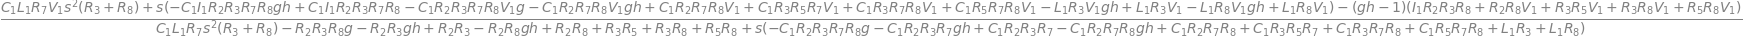

In [22]:
U_sym[v1].collect(s, factor, exact=False)

In [25]:
temp = f'$v_1(s) = {U_sym[v1].collect(s, factor, exact=False)}$'

In [26]:
temp

'$v_1(s) = (C1*L1*R7*V1*s**2*(R3 + R8) + s*(-C1*I1*R2*R3*R7*R8*g*h + C1*I1*R2*R3*R7*R8 - C1*R2*R3*R7*R8*V1*g - C1*R2*R7*R8*V1*g*h + C1*R2*R7*R8*V1 + C1*R3*R5*R7*V1 + C1*R3*R7*R8*V1 + C1*R5*R7*R8*V1 - L1*R3*V1*g*h + L1*R3*V1 - L1*R8*V1*g*h + L1*R8*V1) - (g*h - 1)*(I1*R2*R3*R8 + R2*R8*V1 + R3*R5*V1 + R3*R8*V1 + R5*R8*V1))/(C1*L1*R7*s**2*(R3 + R8) - R2*R3*R8*g - R2*R3*g*h + R2*R3 - R2*R8*g*h + R2*R8 + R3*R5 + R3*R8 + R5*R8 + s*(-C1*R2*R3*R7*R8*g - C1*R2*R3*R7*g*h + C1*R2*R3*R7 - C1*R2*R7*R8*g*h + C1*R2*R7*R8 + C1*R3*R5*R7 + C1*R3*R7*R8 + C1*R5*R7*R8 + L1*R3 + L1*R8))$'

In [27]:
temp1 = temp.replace('**','^').replace('*',' ')
temp1

'$v_1(s) = (C1 L1 R7 V1 s^2 (R3 + R8) + s (-C1 I1 R2 R3 R7 R8 g h + C1 I1 R2 R3 R7 R8 - C1 R2 R3 R7 R8 V1 g - C1 R2 R7 R8 V1 g h + C1 R2 R7 R8 V1 + C1 R3 R5 R7 V1 + C1 R3 R7 R8 V1 + C1 R5 R7 R8 V1 - L1 R3 V1 g h + L1 R3 V1 - L1 R8 V1 g h + L1 R8 V1) - (g h - 1) (I1 R2 R3 R8 + R2 R8 V1 + R3 R5 V1 + R3 R8 V1 + R5 R8 V1))/(C1 L1 R7 s^2 (R3 + R8) - R2 R3 R8 g - R2 R3 g h + R2 R3 - R2 R8 g h + R2 R8 + R3 R5 + R3 R8 + R5 R8 + s (-C1 R2 R3 R7 R8 g - C1 R2 R3 R7 g h + C1 R2 R3 R7 - C1 R2 R7 R8 g h + C1 R2 R7 R8 + C1 R3 R5 R7 + C1 R3 R7 R8 + C1 R5 R7 R8 + L1 R3 + L1 R8))$'

Apply subscripts to most variables, some manual editing will be required.

In [31]:
pattern = r'([a-zA-Z])(\d)'
replacement = r'\1_\2'
new_string = re.sub(pattern, replacement, temp1)
new_string += '<ex5_v1_node_equ>'
new_string

'$v_1(s) = (C_1 L_1 R_7 V_1 s^2 (R_3 + R_8) + s (-C_1 I_1 R_2 R_3 R_7 R_8 g h + C_1 I_1 R_2 R_3 R_7 R_8 - C_1 R_2 R_3 R_7 R_8 V_1 g - C_1 R_2 R_7 R_8 V_1 g h + C_1 R_2 R_7 R_8 V_1 + C_1 R_3 R_5 R_7 V_1 + C_1 R_3 R_7 R_8 V_1 + C_1 R_5 R_7 R_8 V_1 - L_1 R_3 V_1 g h + L_1 R_3 V_1 - L_1 R_8 V_1 g h + L_1 R_8 V_1) - (g h - 1) (I_1 R_2 R_3 R_8 + R_2 R_8 V_1 + R_3 R_5 V_1 + R_3 R_8 V_1 + R_5 R_8 V_1))/(C_1 L_1 R_7 s^2 (R_3 + R_8) - R_2 R_3 R_8 g - R_2 R_3 g h + R_2 R_3 - R_2 R_8 g h + R_2 R_8 + R_3 R_5 + R_3 R_8 + R_5 R_8 + s (-C_1 R_2 R_3 R_7 R_8 g - C_1 R_2 R_3 R_7 g h + C_1 R_2 R_3 R_7 - C_1 R_2 R_7 R_8 g h + C_1 R_2 R_7 R_8 + C_1 R_3 R_5 R_7 + C_1 R_3 R_7 R_8 + C_1 R_5 R_7 R_8 + L_1 R_3 + L_1 R_8))$<ex5_equ_2>'

Manually break equation into lengths of about 90 characters per long line with `\`. Fix any problems and copy paste into Typst.

```
$
v_1(s) = 
(-I_1 R_2 R_3 R_8 g h + I_1 R_2 R_3 R_8 - R_2 R_8 V_1 g h + R_2 R_8 V_1 - R_3 R_5 V_1 g h + \  
R_3 R_5 V_1 - R_3 R_8 V_1 g h + R_3 R_8 V_1 - R_5 R_8 V_1 g h + R_5 R_8 V_1 + \  
s^2 (C_1 L_1 R_3 R_7 V_1 + C_1 L_1 R_7 R_8 V_1) + s (-C_1 I_1 R_2 R_3 R_7 R_8 g h + \  
C_1 I_1 R_2 R_3 R_7 R_8 - C_1 R_2 R_3 R_7 R_8 V_1 g - C_1 R_2 R_7 R_8 V_1 g h + \  
C_1 R_2 R_7 R_8 V_1 + C_1 R_3 R_5 R_7 V_1 + C_1 R_3 R_7 R_8 V_1 + C_1 R_5 R_7 R_8 V_1 - \ 
L_1 R_3 V_1 g h + L_1 R_3 V_1 - L_1 R_8 V_1 g h + L_1 R_8 V_1))

/

(-R_2 R_3 R_8 g - R_2 R_3 g h + R_2 R_3 - R_2 R_8 g h + R_2 R_8 + R_3 R_5 + R_3 R_8 + \
R_5 R_8 + s^2 (C_1 L_1 R_3 R_7 + C_1 L_1 R_7 R_8) + s (-C_1 R_2 R_3 R_7 R_8 g - \ 
C_1 R_2 R_3 R_7 g h + C_1 R_2 R_3 R_7 - C_1 R_2 R_7 R_8 g h + C_1 R_2 R_7 R_8 + \  
C_1 R_3 R_5 R_7 + C_1 R_3 R_7 R_8 + C_1 R_5 R_7 R_8 + L_1 R_3 + L_1 R_8))
$
```

Nevertheless, the solution for node voltage $v_1$ is shown below for illustration purposes. The expression for $v_1$ is of the form:

#### DC Operating Point Solution
The solution to the network equations at $\omega=0$ is called the DC Operating Point solution and is the steady-state direct current (DC) voltage and current conditions of a circuit when no input AC signal is applied. In the netlist $V_1$ is set to zero. Get the element values from the network dataframe.

In [114]:
element_values = SymMNA.get_part_values(network_df)

Set the value of $V_1$ to zero.

In [115]:
element_values[V1] = 0; 

Substitute the numerical values into the equations.

In [116]:
# substitute numerical values
NE_dc = NE_sym.subs(element_values)

The circuit's node voltages and unknown currents can be solved for at individual frequencies. In the code cell below, a frequency of $s=j \omega = 0$ is used to evaluate the equations.

In [117]:
omega = 0 #frequency = DC
NE_dc = NE_dc.subs({s:1j*omega})

U_dc = solve(NE_dc,X)

table_header = ['unknown', 'Op Point','Units']
table_row = []

for name, value in U_dc.items():
    if str(name)[0] == 'v':
        table_row.append([str(name),float(value),'volts'])
    if str(name)[0] == 'I':
        table_row.append([str(name),float(value),'amps'])

print(tabulate(table_row, headers=table_header,colalign = ('left','decimal','left'),tablefmt="simple",floatfmt=('s','.6f','s')))

unknown      Op Point  Units
---------  ----------  -------
v1           3.560440  volts
v2           3.560440  volts
v3           3.560440  volts
v4          -5.340659  volts
v5           3.560440  volts
v6           0.593407  volts
v7           5.340659  volts
v8           0.593407  volts
I_V1        -0.263736  amps
I_V2         1.780220  amps
I_H         -0.593407  amps
I_L1         0.593407  amps


The results above agree with those obtained from LTSpice.

```
       --- Operating Point ---

V(6):	 0.593407	 voltage
V(1):	 3.56044	 voltage
V(4):	 -5.34066	 voltage
V(3):	 3.56044	 voltage
V(7):	 5.34066	 voltage
V(5):	 3.56044	 voltage
V(8):	 0.593407	 voltage
V(2):	 3.56044	 voltage
I(C1):	 0	 device_current
I(H):	 -0.593407	 device_current
I(L1):	 0.593407	 device_current
I(I1):	 3	 device_current
I(R1):	 1.78022	 device_current
I(R2):	 -0.593407	 device_current
I(R3):	 -0.32967	 device_current
I(R5):	 0.593407	 device_current
I(R7):	 0	 device_current
I(R8):	 1.48352	 device_current
I(G):	 -1.78022	 device_current
I(V1):	 -0.263736	 device_current
I(V2):	 1.78022	 device_current


```

Code to generate formatted text for Typst for a table

In [118]:
typst_table_string = '#figure(\n\ttable(\n\tcolumns: 3,\n\tstroke: none,\ntable.header[unknown][Op Point][Units],\n'

for row in table_row:
    typst_table_string += f'[${row[0]}$],[{float(row[1]):,.6f}],[{row[2]}],\n'

typst_table_string += '\t),\n\tcaption: [Operating point results],\n) <ex5_DC_results_table>\n'
print(typst_table_string)

#figure(
	table(
	columns: 3,
	stroke: none,
table.header[unknown][Op Point][Units],
[$v1$],[3.560440],[volts],
[$v2$],[3.560440],[volts],
[$v3$],[3.560440],[volts],
[$v4$],[-5.340659],[volts],
[$v5$],[3.560440],[volts],
[$v6$],[0.593407],[volts],
[$v7$],[5.340659],[volts],
[$v8$],[0.593407],[volts],
[$I_V1$],[-0.263736],[amps],
[$I_V2$],[1.780220],[amps],
[$I_H$],[-0.593407],[amps],
[$I_L1$],[0.593407],[amps],
	),
	caption: [Operating point results],
) <ex5_dc_results_table>



#### AC Analysis at $\omega = 1$
A frequency of $\omega=1$ was arbituarily chosen for the analysis. The component values are reloaded from the network dataframe with the following code.

In [119]:
element_values = SymMNA.get_part_values(network_df)

The DC current source $I_1$ is set to zero.

In [120]:
element_values[I1] = 0; 

The numerical values are substituted into the network equations.

In [121]:
# substitute numerical values
NE_w1 = NE_sym.subs(element_values)

The circuit's node voltages and unknown currents can be solved for at individual frequencies. In the code cell below, a frequency of 1 radian per second is used to evaluate the network equations.

In [122]:
omega = 1 # rad/sec
NE_w1 = NE_w1.subs({s:1j*omega})

U_w1 = solve(NE_w1,X)

table_header = ['unknown', 'mag','phase, deg', 'units']
table_row = []

for name, value in U_w1.items():
    if str(name)[0] == 'v':
        table_row.append([str(name),float(abs(value)),float(arg(value)*180/np.pi),'volts'])
    if str(name)[0] == 'I':
        table_row.append([str(name),float(abs(value)),float(arg(value)*180/np.pi),'amps'])

print(tabulate(table_row, headers=table_header,colalign = ('left','decimal','decimal','left'),tablefmt="simple",floatfmt=('5s','.6f','.6f','s')))

unknown          mag    phase, deg  units
---------  ---------  ------------  -------
v1         12.327333     39.304107  volts
v2         12.327333     39.304107  volts
v3          6.981493     26.458441  volts
v4          6.086848    179.697882  volts
v5          7.822187     93.379955  volts
v6         14.192228     58.245503  volts
v7         10.472239     26.458441  volts
v8          3.442121    -17.718253  volts
I_V1        4.630794   -178.801918  amps
I_V2        3.490746     26.458441  amps
I_H         3.442121    162.281747  amps
I_L1        3.442121    -17.718253  amps


The results shown above agree with those obtained from LTSpice.

```
       --- AC Analysis ---

frequency:	0.159155	Hz
V(6):	mag:    14.1922 phase:    58.2455° 	voltage
V(1):	mag:    12.3273 phase:    39.3041° 	voltage
V(4):	mag:    6.08685 phase:    179.698° 	voltage
V(3):	mag:    6.98149 phase:    26.4584° 	voltage
V(7):	mag:    10.4722 phase:    26.4584° 	voltage
V(5):	mag:    7.82219 phase:      93.38° 	voltage
V(8):	mag:    3.44212 phase:   -17.7183° 	voltage
V(2):	mag:    12.3273 phase:    39.3041° 	voltage
I(C1):	mag:   0.819232 phase:     55.008° 	device_current
I(H):	mag:    3.44212 phase:    162.282° 	device_current
I(L1):	mag:    3.44212 phase:   -17.7183° 	device_current
I(I1):	mag:          0 phase:          0° 	device_current
I(R1):	mag:    3.49075 phase:    26.4584° 	device_current
I(R2):	mag:    3.44212 phase:    162.282° 	device_current
I(R3):	mag:    1.00019 phase:    28.2396° 	device_current
I(R5):	mag:    3.44212 phase:   -17.7183° 	device_current
I(R7):	mag:   0.819232 phase:     55.008° 	device_current
I(R8):	mag:    2.36774 phase:    -64.083° 	device_current
I(G):	mag:    3.49075 phase:   -153.542° 	device_current
I(V1):	mag:    4.63079 phase:   -178.802° 	device_current
I(V2):	mag:    3.49075 phase:    26.4584° 	device_current
```

In [123]:
typst_table_string = '#figure(\n\ttable(\n\tcolumns: 3,\n\tstroke: none,\ntable.header[unknown][Op Point][Units],\n'

for row in table_row:
    typst_table_string += f'[${row[0]}$],[{float(row[1]):,.6f}],[{row[2]}],\n'

typst_table_string += '\t),\n\tcaption: [AC analysis results],\n) <ex5_ac_results_table>\n'
print(typst_table_string)

#figure(
	table(
	columns: 3,
	stroke: none,
table.header[unknown][Op Point][Units],
[$v1$],[12.327333],[39.30410677345189],
[$v2$],[12.327333],[39.30410677345189],
[$v3$],[6.981493],[26.458440999941015],
[$v4$],[6.086848],[179.6978824010276],
[$v5$],[7.822187],[93.37995495492912],
[$v6$],[14.192228],[58.24550312351385],
[$v7$],[10.472239],[26.458440999941015],
[$v8$],[3.442121],[-17.718253408559672],
[$I_V1$],[4.630794],[-178.80191783666675],
[$I_V2$],[3.490746],[26.458440999941015],
[$I_H$],[3.442121],[162.28174659144034],
[$I_L1$],[3.442121],[-17.718253408559672],
	),
	caption: [AC analysis results],
) <ex5_ac_results_table>



## Discussion and Conclusion
This paper serves as a practical procedure for performing symbolic circuit analysis using the Python programming language and its associated scientific libraries, such as SymPy and NumPy. The primary goal is to provide a systematic and computationally efficient procedure for analyzing linear electric circuits, utilizing JupyterLab Notebooks as adaptable templates. MNA is an essential extension of standard nodal analysis that allows all types of circuit elements (including voltage sources, inductors, and dependent sources) to be incorporated into a single, unified matrix formulation.

Key Concepts:

- Symbolic Analysis: This technique calculates a circuit's behavior (e.g., gain, impedance) with components and frequency represented by symbols instead of numerical values. This provides qualitative insight into the circuit's operation, aids in design optimization, and yields exact analytical solutions that numerical simulators (like SPICE) cannot.
- Modified Nodal Analysis (MNA): The procedure leverages MNA to formulate the circuit problem as a system of simultaneous linear equations, $\mathbf{G} \cdot \mathbf{V} = \mathbf{I}$, which is then solved using Linear Algebra techniques (matrix inversion) implemented in Python.
- Advanced Concepts (The s-Domain): The procedure utilaizes Laplace Transformed Circuit Models, which convert time-domain differential equations into simpler algebraic equations in the s-domain (complex frequency domain). This is crucial for analyzing circuits with energy storage elements (capacitors and inductors) and determining their transient and transfer functions.

## Python Code Availability
The Python code and computation results presented in this paper are contained in a JupyterLab notebook which is hosted on GitHub (https://github.com/Tiburonboy/EE_jupyter_notebooks/tree/main/Circuit_analysis_with_python).

Reference List Entry (To match the bracketed citation [1])

Include the formal citation for your archived release in your References section:

    IEEE / Numerical Style:

        [1] J. Smith and A. Johnson, "Software and datasets for [paper title]," ver. 1.0.0, Zenodo, 2026. doi: 10.5281/zenodo.XXXXXXX.

    APA Style:

        Smith, J., & Johnson, A. (2026). Software and datasets for [paper title] (Version v1.0.0) [Data set]. Zenodo. https://doi.org/10.5281/zenodo.XXXXXXX